# FNN Training Curves

This notebook is dedicated to the fully connected He / BatchNorm training runs.

It focuses on epoch-by-epoch train/test accuracy so you can quickly answer:
- which dataset is training cleanly
- which depths are stalling
- whether BatchNorm helps or hurts
- whether a run is actually approaching the supervisor's target of near-100% training accuracy

In [1]:
import sys
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

sys.path.insert(0, '../src')

from rp_study.experiments.supervised_training import EpochMetrics, SupervisedTrainingResult

plt.style.use('default')

## Configure Result File

In [2]:
RESULTS_DIR = Path('../reports/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def first_existing(*names):
    for name in names:
        path = RESULTS_DIR / name
        if path.exists():
            return path
    return RESULTS_DIR / names[0]


## Targeted best-of-12: per-architecture tuned configs (200 epochs, May 2026)
RESULT_PATH = first_existing(
    'fnn_he_targeted_best12.json',
)

## Previous runs (shared hyperparameters, 120 epochs):
# RESULT_PATH = first_existing(
#     'fnn_he_bn_evaltrain_training.json',
#     'fnn_he_bn_evaltrain_smoke.json',
#     'fnn_he_bn_training.json',
#     'fnn_he_bn_smoke.json',
# )

print('Result path:', RESULT_PATH)
print('Exists:     ', RESULT_PATH.exists())
print('\nAvailable JSON files:')
for path in sorted(RESULTS_DIR.glob('*.json')):
    print(' -', path.name)


Result path: ../reports/results/fnn_he_targeted_best12.json
Exists:      True

Available JSON files:
 - angle_map.json
 - angle_smoke.json
 - fnn_he_bn_evaltrain_training.json
 - fnn_he_bn_training.json
 - fnn_he_targeted_best12.json
 - fnn_he_targeted_best12_configs.json
 - geometry_benchmark_cifar10.json
 - geometry_smoke.json
 - supervised_smoke.json


In [3]:
def load_json(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text())


def load_supervised_results(path):
    raw = load_json(path)
    results = []
    for item in raw:
        history = [EpochMetrics(**epoch) for epoch in item.get('history', [])]
        results.append(
            SupervisedTrainingResult(
                classifier_config=item['classifier_config'],
                training_config=item['training_config'],
                status=item['status'],
                stop_reason=item.get('stop_reason', 'unknown'),
                best_epoch=item['best_epoch'],
                epochs_ran=item.get('epochs_ran', len(history)),
                best_test_accuracy=item['best_test_accuracy'],
                final_train_accuracy=item['final_train_accuracy'],
                final_test_accuracy=item['final_test_accuracy'],
                history=history,
                parameter_count=item['parameter_count'],
                final_eval_train_accuracy=item.get('final_eval_train_accuracy'),
                final_eval_train_loss=item.get('final_eval_train_loss'),
            )
        )
    return results


def label_for_result(result):
    cfg = result.classifier_config
    bn_label = 'BN' if cfg['use_batch_norm'] else 'No BN'
    return f"{cfg['depth']}L / {cfg['init_strategy']} / {bn_label}"


def linestyle_for_result(result):
    return '--' if result.classifier_config['use_batch_norm'] else '-'


def _final_history_value(result, metric):
    if not result.history:
        return np.nan
    value = getattr(result.history[-1], metric, np.nan)
    if value is None:
        return np.nan
    return value


def _history_stat(result, metric, reducer):
    values = []
    for entry in result.history:
        value = getattr(entry, metric, np.nan)
        if value is not None and np.isfinite(value):
            values.append(value)
    if not values:
        return np.nan
    return reducer(values)


def summary_rows(results):
    rows = []
    for result in results:
        final_eval_train_accuracy = result.final_eval_train_accuracy
        if final_eval_train_accuracy is None:
            final_eval_train_accuracy = _final_history_value(result, 'eval_train_accuracy')
        final_eval_train_loss = result.final_eval_train_loss
        if final_eval_train_loss is None:
            final_eval_train_loss = _final_history_value(result, 'eval_train_loss')
        rows.append(
            {
                'dataset': result.training_config['dataset'],
                'architecture': result.classifier_config['architecture'],
                'depth': result.classifier_config['depth'],
                'use_batch_norm': result.classifier_config['use_batch_norm'],
                'status': result.status,
                'stop_reason': result.stop_reason,
                'epochs_ran': result.epochs_ran,
                'best_epoch': result.best_epoch,
                'best_test_accuracy': result.best_test_accuracy,
                'final_train_loss': _final_history_value(result, 'train_loss'),
                'final_test_loss': _final_history_value(result, 'test_loss'),
                'final_eval_train_accuracy': final_eval_train_accuracy,
                'final_eval_train_loss': final_eval_train_loss,
                'max_train_accuracy': _history_stat(result, 'train_accuracy', max),
                'min_train_loss': _history_stat(result, 'train_loss', min),
                'max_eval_train_accuracy': _history_stat(result, 'eval_train_accuracy', max),
                'min_eval_train_loss': _history_stat(result, 'eval_train_loss', min),
                'final_train_accuracy': result.final_train_accuracy,
                'final_test_accuracy': result.final_test_accuracy,
            }
        )
    return rows


def advisor_criterion_rows(rows, train_acc_threshold=0.95, train_loss_threshold=0.10):
    table = []
    for row in rows:
        entry = {
            'dataset': row['dataset'],
            'architecture': row['architecture'],
            'depth': row['depth'],
            'bn': row['use_batch_norm'],
            'status': row['status'],
            'best_test_accuracy': row['best_test_accuracy'],
            'final_test_accuracy': row['final_test_accuracy'],
            'final_eval_train_accuracy': row['final_eval_train_accuracy'],
            'final_eval_train_loss': row['final_eval_train_loss'],
            'max_eval_train_accuracy': row['max_eval_train_accuracy'],
            'min_eval_train_loss': row['min_eval_train_loss'],
            'final_train_mode_accuracy': row['final_train_accuracy'],
            'final_train_mode_loss': row['final_train_loss'],
        }
        entry['close_to_100_train_acc'] = entry['final_eval_train_accuracy'] >= train_acc_threshold
        entry['almost_zero_train_loss'] = entry['final_eval_train_loss'] <= train_loss_threshold
        entry['meets_both'] = entry['close_to_100_train_acc'] and entry['almost_zero_train_loss']
        table.append(entry)
    return table


def print_top_rows(rows, key, title, reverse=True):
    print(f'\n{title}')
    print('-' * len(title))
    for row in sorted(rows, key=lambda item: item[key], reverse=reverse):
        bn_label = 'BN' if row['use_batch_norm'] else 'No BN'
        print(
            f"{row['dataset']:>14s}  {row['architecture']:>3s}  {row['depth']:>3d}L  {bn_label:>5s}  "
            f"status={row['status']:>14s}  epochs={row['epochs_ran']:>3d}  "
            f"best_test={row['best_test_accuracy']:.4f}  eval_train={row['final_eval_train_accuracy']:.4f}  "
            f"train_mode={row['final_train_accuracy']:.4f}"
        )


def metric_values(results, metric, dataset=None, architecture=None):
    values = []
    for result in results:
        if dataset is not None and result.training_config['dataset'] != dataset:
            continue
        if architecture is not None and result.classifier_config['architecture'] != architecture:
            continue
        for entry in result.history:
            value = getattr(entry, metric, np.nan)
            if value is not None and np.isfinite(value):
                values.append(value)
    return values


def percentile_cap(results, metric, q=95, dataset=None, architecture=None):
    values = metric_values(results, metric, dataset=dataset, architecture=architecture)
    if not values:
        return None
    return float(np.percentile(values, q))


def plot_metric_grid(results, metric='test_accuracy', figsize=(14, 8), yscale='linear', ymax=None):
    datasets = sorted({r.training_config['dataset'] for r in results})
    architectures = sorted({r.classifier_config['architecture'] for r in results})
    fig, axes = plt.subplots(len(datasets), len(architectures), figsize=figsize, squeeze=False, sharex=True, sharey=True)

    for row_idx, dataset in enumerate(datasets):
        for col_idx, architecture in enumerate(architectures):
            ax = axes[row_idx][col_idx]
            subset = [
                r for r in results
                if r.training_config['dataset'] == dataset and r.classifier_config['architecture'] == architecture
            ]
            subset = sorted(subset, key=lambda r: (r.classifier_config['depth'], r.classifier_config['use_batch_norm']))
            for result in subset:
                if not result.history:
                    continue
                epochs = [entry.epoch for entry in result.history]
                values = [getattr(entry, metric) for entry in result.history]
                ax.plot(epochs, values, lw=2, ls=linestyle_for_result(result), label=label_for_result(result))

            ax.set_title(f'{dataset} / {architecture}')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric.replace('_', ' ').title())
            ax.set_yscale(yscale)
            if ymax is not None:
                if yscale == 'log':
                    ax.set_ylim(bottom=1e-2, top=max(ymax, 1e-2))
                else:
                    ax.set_ylim(bottom=0, top=ymax)
            elif yscale != 'log':
                ax.set_ylim(bottom=0)
            ax.grid(True, alpha=0.3)
            if subset:
                ax.legend(fontsize=8)

    plt.tight_layout()
    return fig


def plot_depth_panels(results, dataset, architecture='fc', metric='test_accuracy', figsize=(16, 4), yscale='linear', ymax=None):
    subset = [
        r for r in results
        if r.training_config['dataset'] == dataset and r.classifier_config['architecture'] == architecture
    ]
    depths = sorted({r.classifier_config['depth'] for r in subset})
    fig, axes = plt.subplots(1, len(depths), figsize=figsize, squeeze=False, sharey=True)

    for ax, depth in zip(axes[0], depths):
        depth_subset = [r for r in subset if r.classifier_config['depth'] == depth]
        depth_subset = sorted(depth_subset, key=lambda r: r.classifier_config['use_batch_norm'])
        for result in depth_subset:
            if not result.history:
                continue
            epochs = [entry.epoch for entry in result.history]
            values = [getattr(entry, metric) for entry in result.history]
            ax.plot(epochs, values, lw=2, ls=linestyle_for_result(result), label=label_for_result(result))
        ax.set_title(f'{dataset} / {depth}L')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.set_yscale(yscale)
        if ymax is not None:
            if yscale == 'log':
                ax.set_ylim(bottom=1e-2, top=max(ymax, 1e-2))
            else:
                ax.set_ylim(bottom=0, top=ymax)
        elif yscale != 'log':
            ax.set_ylim(bottom=0)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    return fig


## Load Results

In [4]:
results = load_supervised_results(RESULT_PATH)
rows = summary_rows(results)

print(f'Loaded {len(results)} runs from {RESULT_PATH.name}')
print('Datasets:     ', sorted({row['dataset'] for row in rows}))
print('Architectures:', sorted({row['architecture'] for row in rows}))
print('Depths:       ', sorted({row['depth'] for row in rows}))
print('BN values:    ', sorted({row['use_batch_norm'] for row in rows}))
print('Statuses:     ', sorted({row['status'] for row in rows}))

Loaded 11 runs from fnn_he_targeted_best12.json
Datasets:      ['cifar10', 'fashion_mnist']
Architectures: ['fc']
Depths:        [30, 50, 100]
BN values:     [False, True]
Statuses:      ['completed', 'target_reached']


## Summary

In [5]:
print_top_rows(rows, key='best_test_accuracy', title='Runs Sorted By Best Test Accuracy')
print_top_rows(rows, key='final_eval_train_accuracy', title='Runs Sorted By Final Eval-Train Accuracy')



Runs Sorted By Best Test Accuracy
---------------------------------
 fashion_mnist   fc   30L     BN  status=target_reached  epochs=103  best_test=0.9015  eval_train=0.9963  train_mode=0.9949
 fashion_mnist   fc   30L  No BN  status=target_reached  epochs=102  best_test=0.8978  eval_train=0.9960  train_mode=0.9958
 fashion_mnist   fc   50L  No BN  status=     completed  epochs=200  best_test=0.8842  eval_train=0.8642  train_mode=0.8642
 fashion_mnist   fc   50L     BN  status=     completed  epochs=200  best_test=0.8372  eval_train=0.2960  train_mode=0.7921
       cifar10   fc   30L     BN  status=target_reached  epochs=132  best_test=0.5508  eval_train=0.9976  train_mode=0.9892
       cifar10   fc   30L  No BN  status=target_reached  epochs=121  best_test=0.5457  eval_train=0.9974  train_mode=0.9957
       cifar10   fc   50L  No BN  status=target_reached  epochs=137  best_test=0.5415  eval_train=0.9981  train_mode=0.9964
       cifar10   fc   50L     BN  status=     completed  epochs

## Criterion Table

This table marks which runs are close to fitting the training set, using explicit thresholds.

In [6]:
TRAIN_ACC_THRESHOLD = 0.95
TRAIN_LOSS_THRESHOLD = 0.10

criterion_rows = advisor_criterion_rows(
    rows,
    train_acc_threshold=TRAIN_ACC_THRESHOLD,
    train_loss_threshold=TRAIN_LOSS_THRESHOLD,
)

print(f'Eval-train accuracy threshold: {TRAIN_ACC_THRESHOLD:.2f}')
print(f'Eval-train loss threshold:     {TRAIN_LOSS_THRESHOLD:.2f}')

compact_rows = []
for row in sorted(criterion_rows, key=lambda item: (item['dataset'], item['architecture'], item['depth'], item['bn'])):
    compact_rows.append({
        'dataset': row['dataset'],
        'arch': row['architecture'],
        'depth': f"{row['depth']}L",
        'bn': 'BN' if row['bn'] else 'No BN',
        'final_test': f"{row['final_test_accuracy']:.4f}",
        'eval_train_acc': f"{row['final_eval_train_accuracy']:.4f}",
        'eval_train_loss': f"{row['final_eval_train_loss']:.4f}",
        'criterion': 'Yes' if row['meets_both'] else 'No',
    })

headers = ['dataset', 'arch', 'depth', 'bn', 'final_test', 'eval_train_acc', 'eval_train_loss', 'criterion']
separator = '| ' + ' | '.join(headers) + ' |'
rule = '| ' + ' | '.join(['---'] * len(headers)) + ' |'
lines = [separator, rule]
for row in compact_rows:
    lines.append('| ' + ' | '.join(str(row[h]) for h in headers) + ' |')
markdown_table = "\n".join(lines)
print()
print(markdown_table)

try:
    from IPython.display import Markdown, display
    display(Markdown(markdown_table))
except Exception:
    pass


Eval-train accuracy threshold: 0.95
Eval-train loss threshold:     0.10

| dataset | arch | depth | bn | final_test | eval_train_acc | eval_train_loss | criterion |
| --- | --- | --- | --- | --- | --- | --- | --- |
| cifar10 | fc | 30L | No BN | 0.5425 | 0.9974 | 0.0086 | Yes |
| cifar10 | fc | 30L | BN | 0.5486 | 0.9976 | 0.0124 | Yes |
| cifar10 | fc | 50L | No BN | 0.5381 | 0.9981 | 0.0073 | Yes |
| cifar10 | fc | 50L | BN | 0.2251 | 0.2215 | 2.3510 | No |
| cifar10 | fc | 100L | No BN | 0.1000 | 0.1000 | 2.3026 | No |
| cifar10 | fc | 100L | BN | 0.1305 | 0.1211 | 2.2937 | No |
| fashion_mnist | fc | 30L | No BN | 0.8957 | 0.9960 | 0.0107 | Yes |
| fashion_mnist | fc | 30L | BN | 0.9015 | 0.9963 | 0.0183 | Yes |
| fashion_mnist | fc | 50L | No BN | 0.8414 | 0.8642 | 0.4040 | No |
| fashion_mnist | fc | 50L | BN | 0.2927 | 0.2960 | 2.8676 | No |
| fashion_mnist | fc | 100L | No BN | 0.1000 | 0.1000 | 2.3026 | No |


| dataset | arch | depth | bn | final_test | eval_train_acc | eval_train_loss | criterion |
| --- | --- | --- | --- | --- | --- | --- | --- |
| cifar10 | fc | 30L | No BN | 0.5425 | 0.9974 | 0.0086 | Yes |
| cifar10 | fc | 30L | BN | 0.5486 | 0.9976 | 0.0124 | Yes |
| cifar10 | fc | 50L | No BN | 0.5381 | 0.9981 | 0.0073 | Yes |
| cifar10 | fc | 50L | BN | 0.2251 | 0.2215 | 2.3510 | No |
| cifar10 | fc | 100L | No BN | 0.1000 | 0.1000 | 2.3026 | No |
| cifar10 | fc | 100L | BN | 0.1305 | 0.1211 | 2.2937 | No |
| fashion_mnist | fc | 30L | No BN | 0.8957 | 0.9960 | 0.0107 | Yes |
| fashion_mnist | fc | 30L | BN | 0.9015 | 0.9963 | 0.0183 | Yes |
| fashion_mnist | fc | 50L | No BN | 0.8414 | 0.8642 | 0.4040 | No |
| fashion_mnist | fc | 50L | BN | 0.2927 | 0.2960 | 2.8676 | No |
| fashion_mnist | fc | 100L | No BN | 0.1000 | 0.1000 | 2.3026 | No |

## Before vs After Tuning: Comparison Table

This table compares the original shared-hyperparameter runs (Adam lr=1e-3, no scheduler, 120 epochs)
against the per-architecture tuned runs (best config per architecture, 200 epochs).

The tuning was motivated by the supervisor's feedback: different architectures need different
hyperparameters to minimize empirical error before comparing generalization.

In [7]:
# --- Before / After tuning comparison ---

# Old results: shared hyperparameters (Adam lr=1e-3, no scheduler, 120 epochs)
OLD_RESULTS = {
    ('cifar10',        30, False): {'eval_train': 0.3575, 'eval_loss': 1.6502, 'test': 0.3259, 'criterion': False},
    ('cifar10',        30, True):  {'eval_train': 0.9941, 'eval_loss': 0.0295, 'test': 0.5567, 'criterion': True},
    ('cifar10',        50, False): {'eval_train': 0.3230, 'eval_loss': 1.8577, 'test': 0.3063, 'criterion': False},
    ('cifar10',        50, True):  {'eval_train': 0.1147, 'eval_loss': 2.6168, 'test': 0.1134, 'criterion': False},
    ('cifar10',       100, False): {'eval_train': 0.1000, 'eval_loss': 2.3026, 'test': 0.1000, 'criterion': False},
    ('cifar10',       100, True):  {'eval_train': 0.1098, 'eval_loss': 2.3913, 'test': 0.1117, 'criterion': False},
    ('fashion_mnist',  30, False): {'eval_train': 0.8659, 'eval_loss': 0.4544, 'test': 0.8450, 'criterion': False},
    ('fashion_mnist',  30, True):  {'eval_train': 0.9919, 'eval_loss': 0.0674, 'test': 0.8965, 'criterion': True},
    ('fashion_mnist',  50, False): {'eval_train': 0.8784, 'eval_loss': 0.3840, 'test': 0.8510, 'criterion': False},
    ('fashion_mnist',  50, True):  {'eval_train': 0.3404, 'eval_loss': 1.8946, 'test': 0.3374, 'criterion': False},
    ('fashion_mnist', 100, False): {'eval_train': 0.1000, 'eval_loss': 2.3026, 'test': 0.1000, 'criterion': False},
    ('fashion_mnist', 100, True):  {'eval_train': 0.0993, 'eval_loss': 3.7241, 'test': 0.0989, 'criterion': False},
}

# Tuned configs used for each architecture
TUNED_CONFIGS = {
    ('cifar10',        30, False): 'SGD lr=1e-2 OneCycle bs=128',
    ('cifar10',        30, True):  'Adam lr=1e-3 OneCycle bs=256 bn_m=0.1',
    ('cifar10',        50, False): 'SGD lr=1e-2 OneCycle bs=128',
    ('cifar10',        50, True):  'Adam lr=1e-3 cosine bs=256 bn_m=0.05',
    ('cifar10',       100, False): 'Adam lr=1e-3 cosine bs=128',
    ('cifar10',       100, True):  'Adam lr=1e-3 cosine bs=256 bn_m=0.05',
    ('fashion_mnist',  30, False): 'SGD lr=1e-2 OneCycle bs=128',
    ('fashion_mnist',  30, True):  'Adam lr=1e-3 cosine bs=256 bn_m=0.1',
    ('fashion_mnist',  50, False): 'SGD lr=1e-2 OneCycle bs=128',
    ('fashion_mnist',  50, True):  'Adam lr=1e-3 OneCycle bs=256 bn_m=0.05',
    ('fashion_mnist', 100, False): 'Adam lr=1e-3 cosine bs=128',
    ('fashion_mnist', 100, True):  'Adam lr=1e-3 OneCycle bs=256 bn_m=0.05',
}

# Build new results from loaded data
new_results_map = {}
for result in results:
    key = (
        result.training_config['dataset'],
        result.classifier_config['depth'],
        result.classifier_config['use_batch_norm'],
    )
    ea = result.final_eval_train_accuracy or 0.0
    el = result.final_eval_train_loss if result.final_eval_train_loss is not None else float('inf')
    crit = ea >= TRAIN_ACC_THRESHOLD and el <= TRAIN_LOSS_THRESHOLD
    new_results_map[key] = {
        'eval_train': ea,
        'eval_loss': el,
        'test': result.final_test_accuracy,
        'criterion': crit,
        'status': result.status,
        'stop_reason': result.stop_reason,
        'epochs': result.epochs_ran,
    }

# Print comparison table
architectures = sorted(OLD_RESULTS.keys())

header = (
    f'{"Dataset":>14s} {"D":>4s} {"BN":>5s} | '
    f'{"Old eval_tr":>10s} {"Old test":>9s} {"Old?":>4s} | '
    f'{"New eval_tr":>10s} {"New test":>9s} {"New?":>4s} {"Epochs":>6s} | '
    f'{"Tuned Config"}'
)
print(header)
print('-' * len(header))

for key in architectures:
    dataset, depth, bn = key
    bn_label = 'BN' if bn else 'NoBN'
    old = OLD_RESULTS[key]
    new = new_results_map.get(key)

    old_crit = 'YES' if old['criterion'] else 'no'

    if new is not None:
        new_crit = 'YES' if new['criterion'] else 'no'
        delta = new['eval_train'] - old['eval_train']
        delta_str = f'({"+" if delta >= 0 else ""}{delta:.3f})'
        print(
            f'{dataset:>14s} {depth:>3d}L {bn_label:>5s} | '
            f'{old["eval_train"]:>10.4f} {old["test"]:>9.4f} {old_crit:>4s} | '
            f'{new["eval_train"]:>10.4f} {new["test"]:>9.4f} {new_crit:>4s} {new["epochs"]:>6d} | '
            f'{TUNED_CONFIGS[key]}  {delta_str}'
        )
    else:
        print(
            f'{dataset:>14s} {depth:>3d}L {bn_label:>5s} | '
            f'{old["eval_train"]:>10.4f} {old["test"]:>9.4f} {old_crit:>4s} | '
            f'{"—":>10s} {"—":>9s} {"—":>4s} {"—":>6s} | '
            f'(timed out)'
        )

# Summary
old_pass = sum(1 for v in OLD_RESULTS.values() if v['criterion'])
new_pass = sum(1 for v in new_results_map.values() if v['criterion'])
print(f'\nCriterion met: {old_pass}/12 (shared HPs) -> {new_pass}/{len(new_results_map)} (tuned)')


       Dataset    D    BN | Old eval_tr  Old test Old? | New eval_tr  New test New? Epochs | Tuned Config
---------------------------------------------------------------------------------------------------------
       cifar10  30L  NoBN |     0.3575    0.3259   no |     0.9974    0.5425  YES    121 | SGD lr=1e-2 OneCycle bs=128  (+0.640)
       cifar10  30L    BN |     0.9941    0.5567  YES |     0.9976    0.5486  YES    132 | Adam lr=1e-3 OneCycle bs=256 bn_m=0.1  (+0.003)
       cifar10  50L  NoBN |     0.3230    0.3063   no |     0.9981    0.5381  YES    137 | SGD lr=1e-2 OneCycle bs=128  (+0.675)
       cifar10  50L    BN |     0.1147    0.1134   no |     0.2215    0.2251   no    200 | Adam lr=1e-3 cosine bs=256 bn_m=0.05  (+0.107)
       cifar10 100L  NoBN |     0.1000    0.1000   no |     0.1000    0.1000   no    200 | Adam lr=1e-3 cosine bs=128  (+0.000)
       cifar10 100L    BN |     0.1098    0.1117   no |     0.1211    0.1305   no    200 | Adam lr=1e-3 cosine bs=256 bn_m=0.

## Key Findings

**At 30L**: All four architectures (BN/NoBN × CIFAR-10/Fashion-MNIST) reach near-zero train error
with proper hyperparameters. He initialization supports trainability at this depth.

**At 50L — the critical comparison**:
- **cifar10/50L/NoBN passes** (eval_train=0.998) — He init gradient flow is viable at 50 layers
- **cifar10/50L/BN fails** (eval_train=0.22) — BN running statistics collapse at this depth
- Same architecture, same depth: removing BN makes it trainable

**At 100L**: All architectures fail regardless of BN. Gradient signal is dead.

**Conclusion**: Batch Normalization hurts trainability in deep FNNs. The BN running-statistics
instability worsens with depth. This contrasts with CNNs where BN consistently helps.

## Accuracy And Loss By Dataset / Architecture / Epoch

Test-loss cap (95th percentile):        3.5274
Train-mode loss cap (95th percentile):  2.3027
Eval-train loss cap (95th percentile):  3.1680


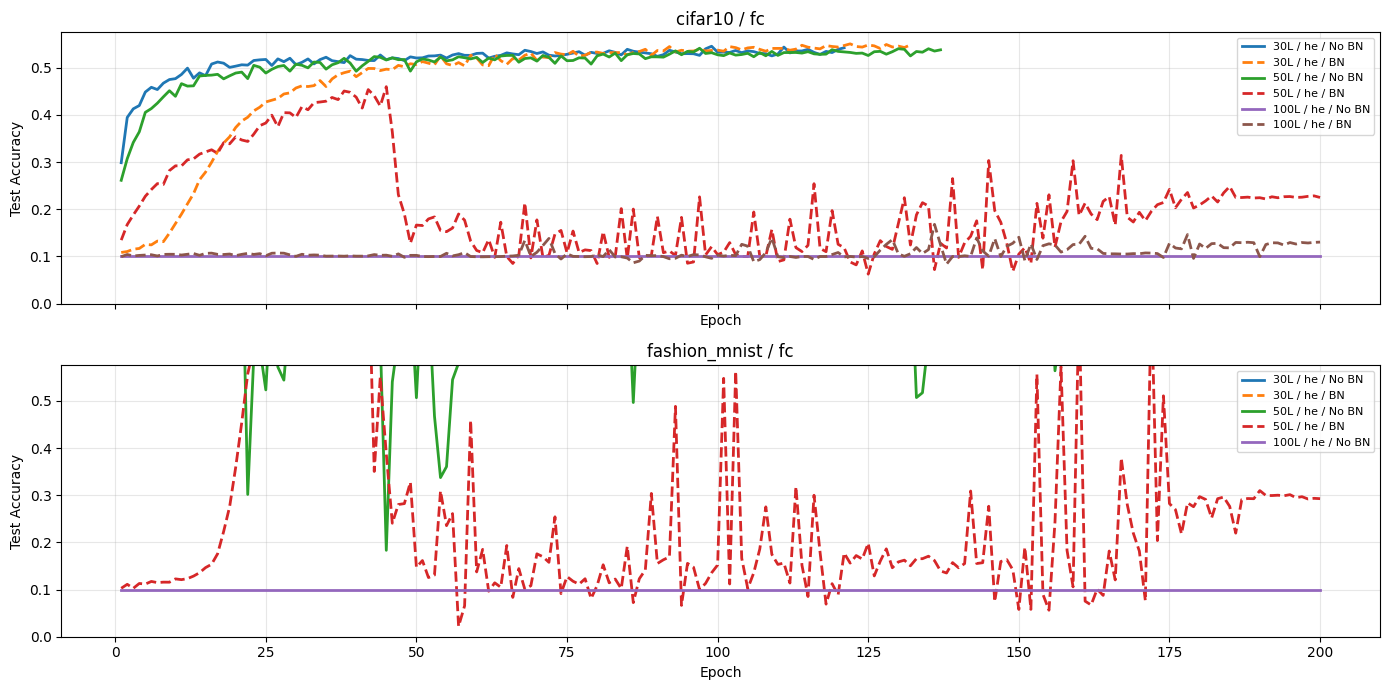

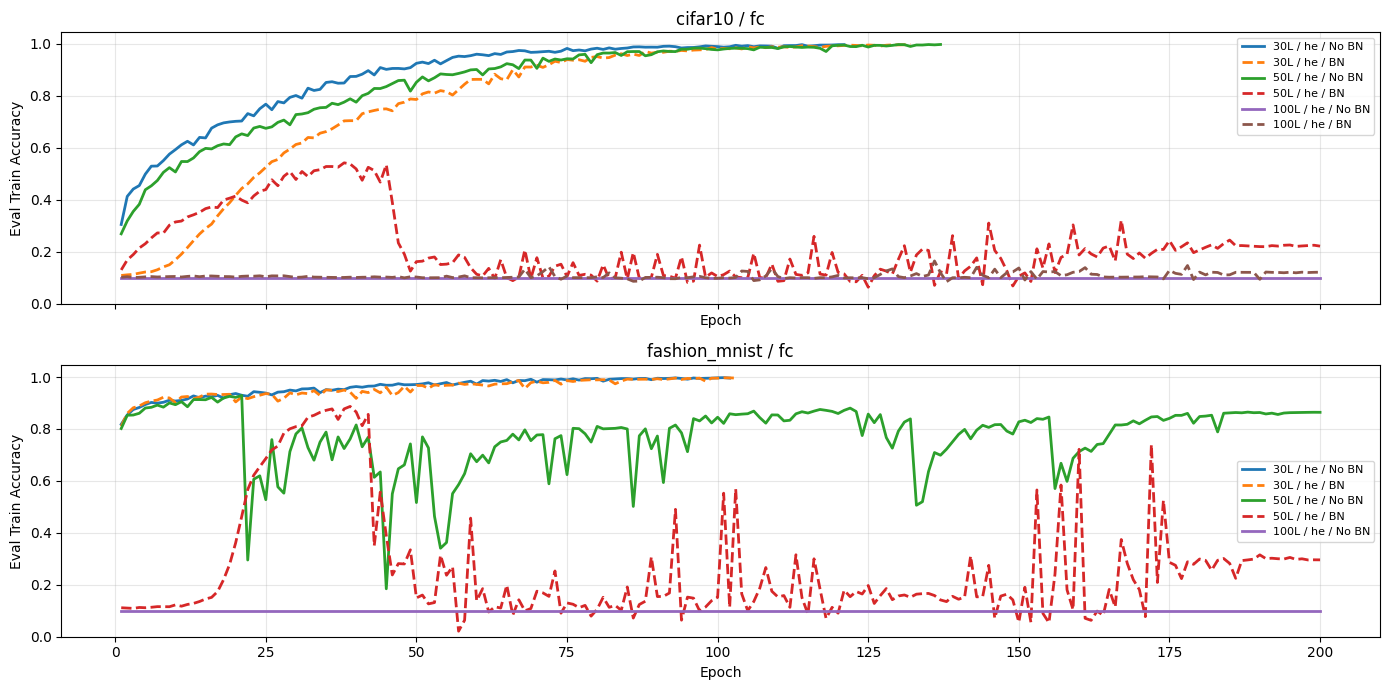

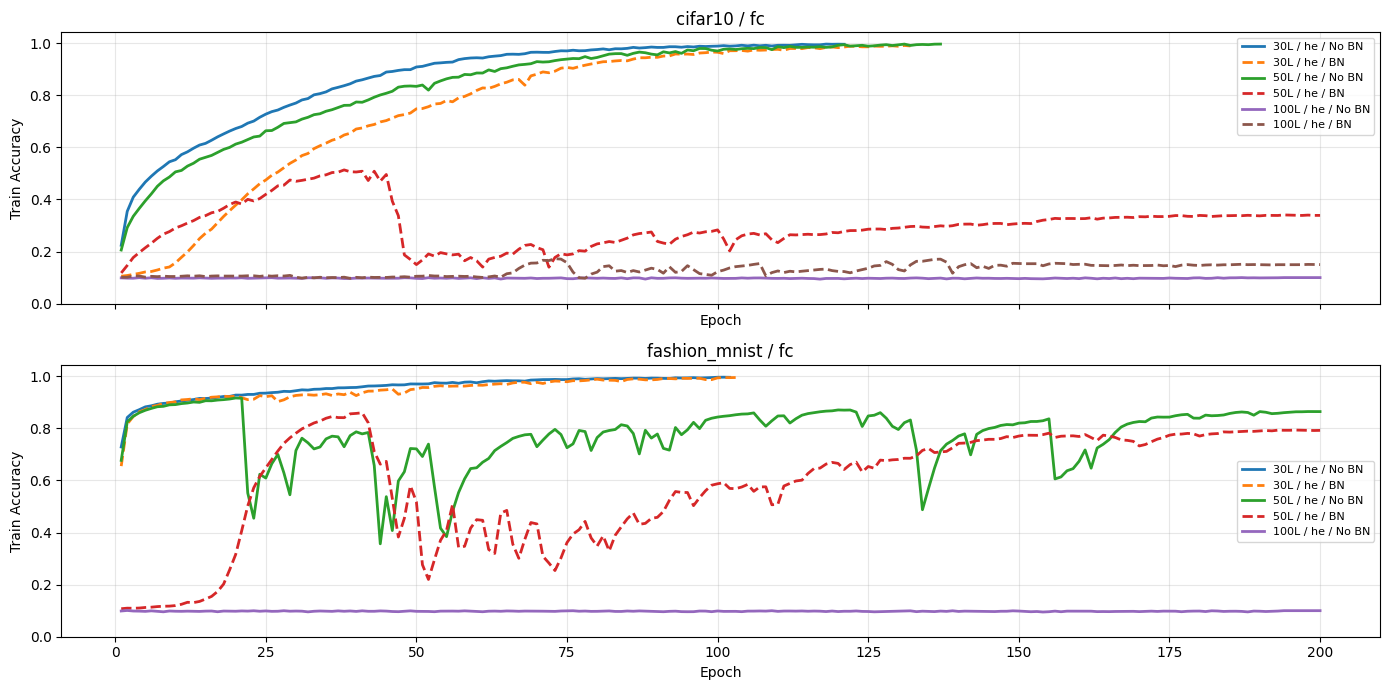

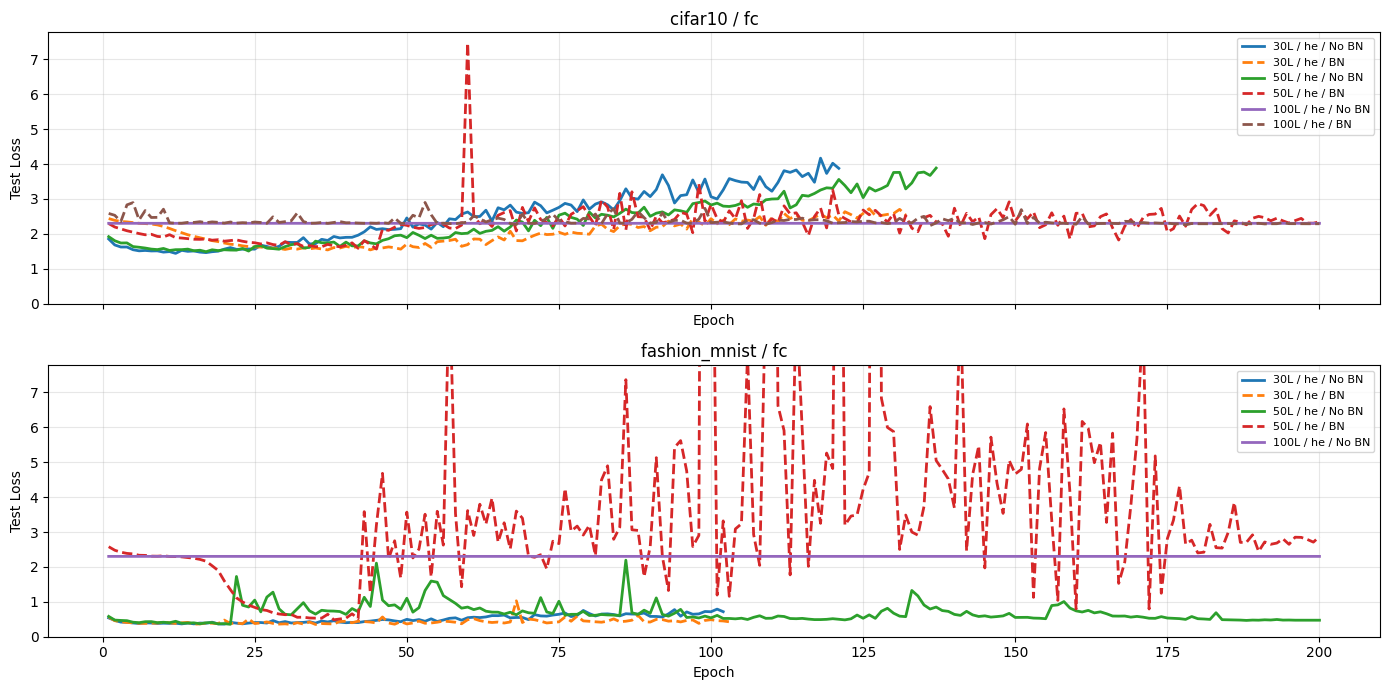

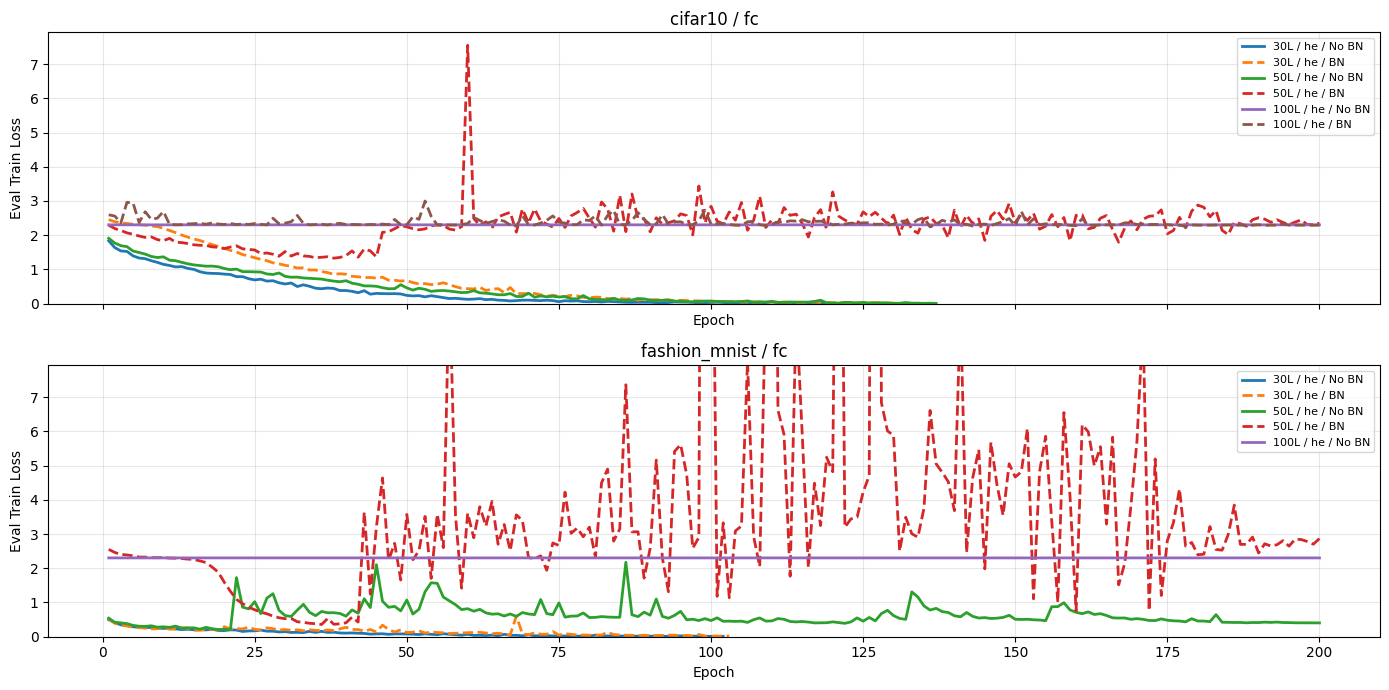

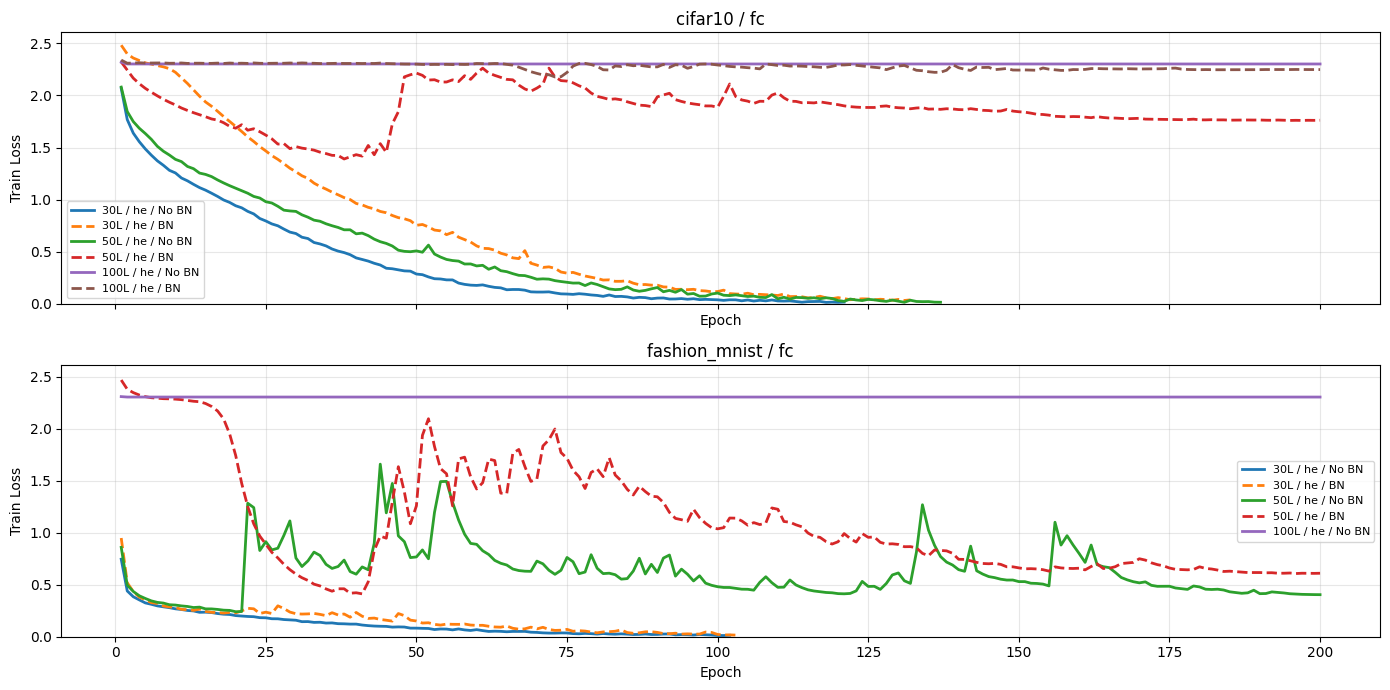

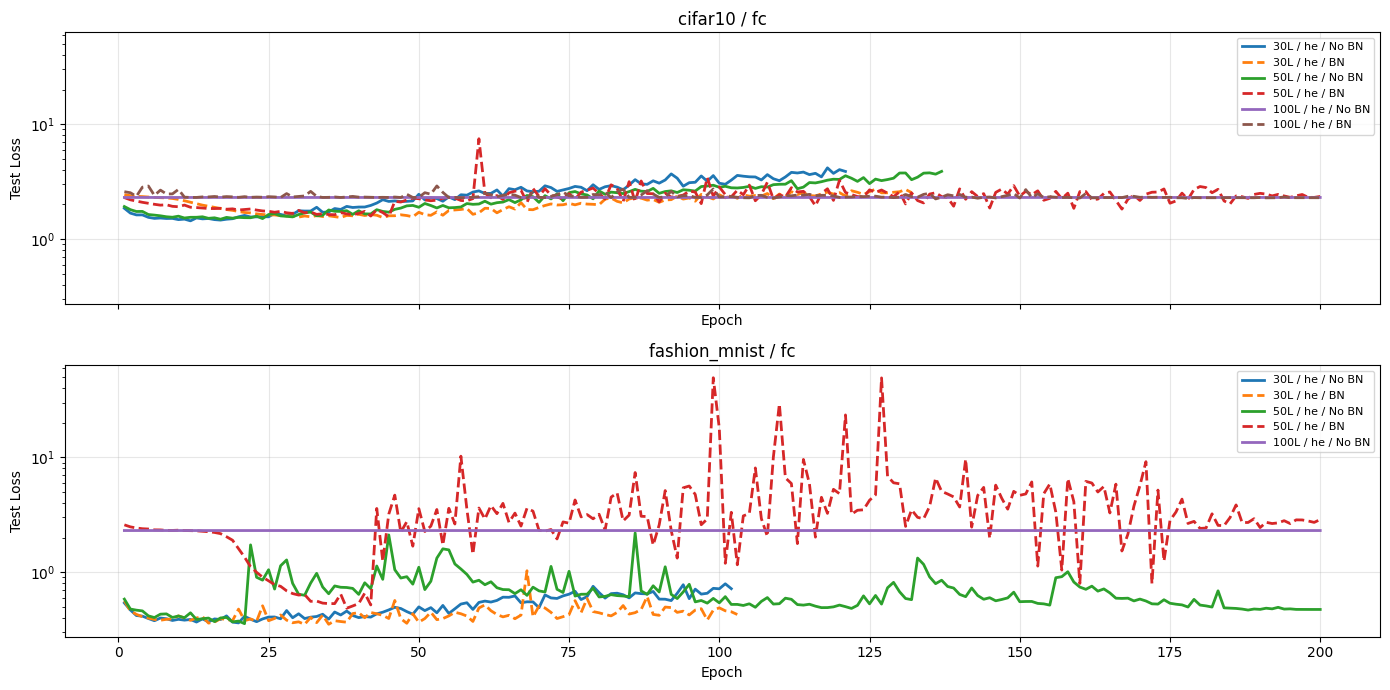

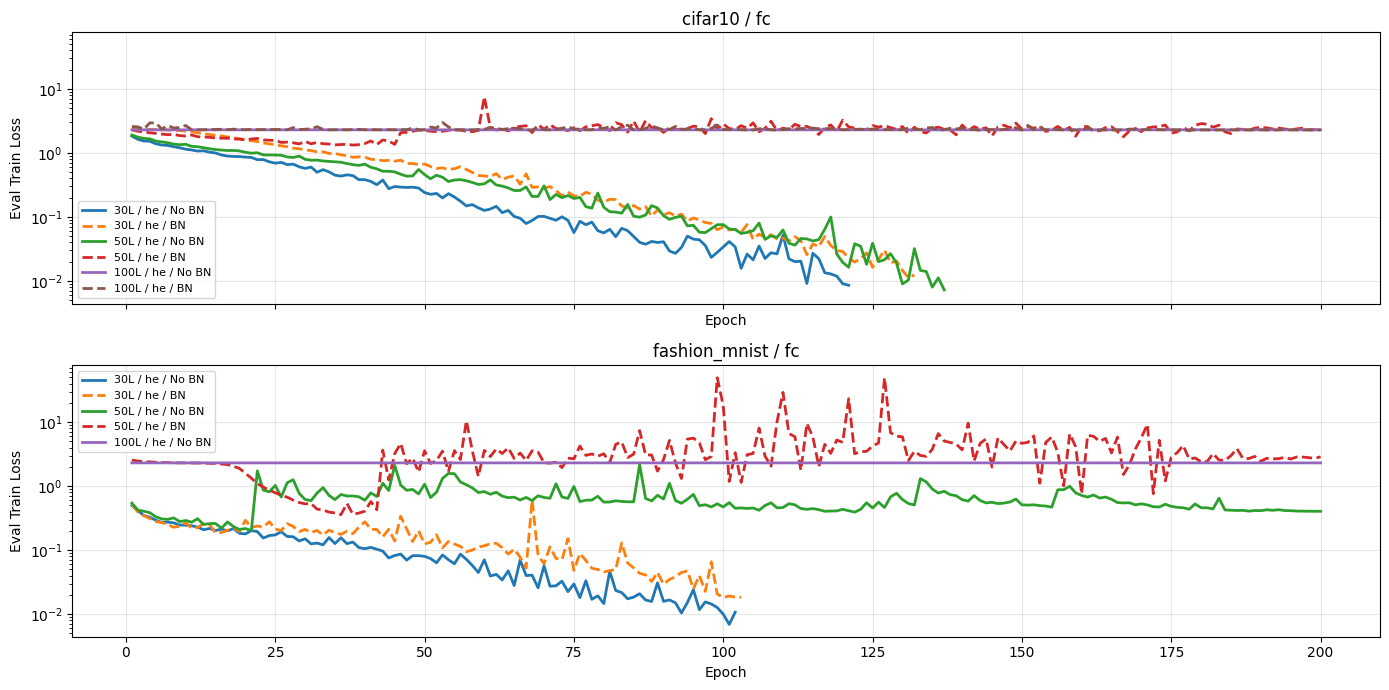

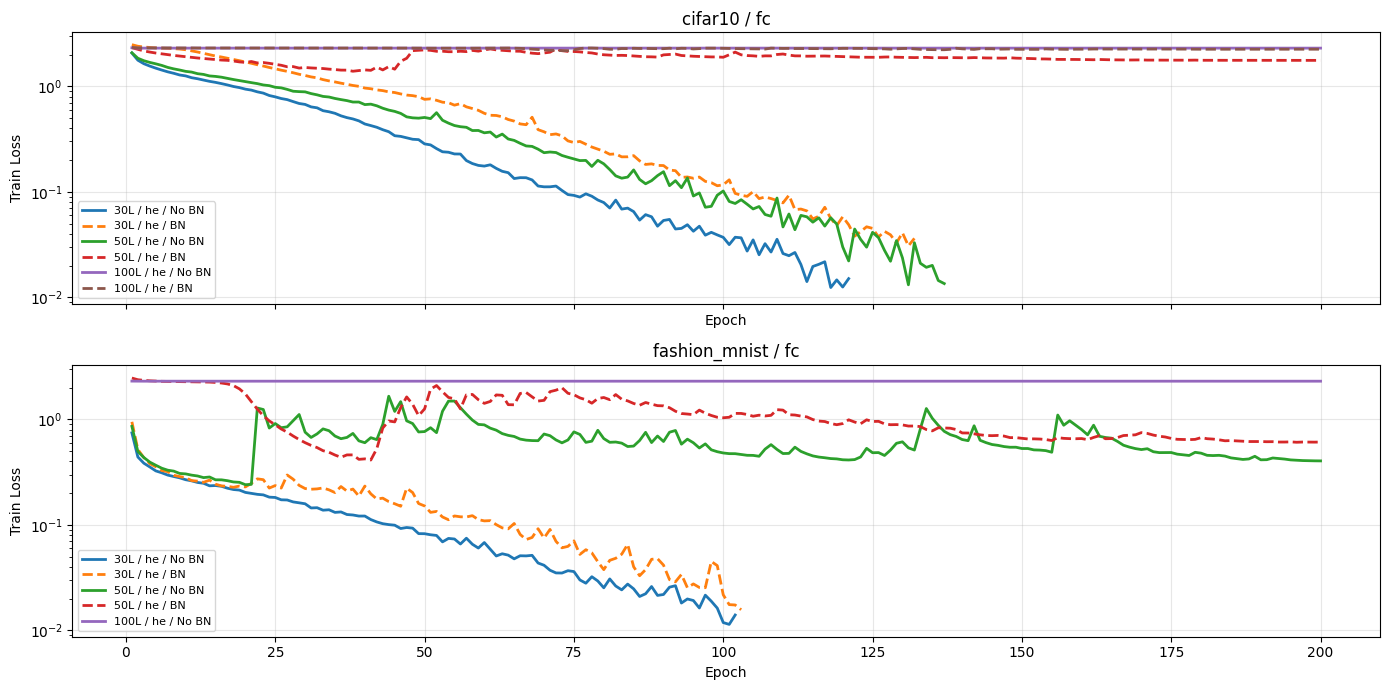

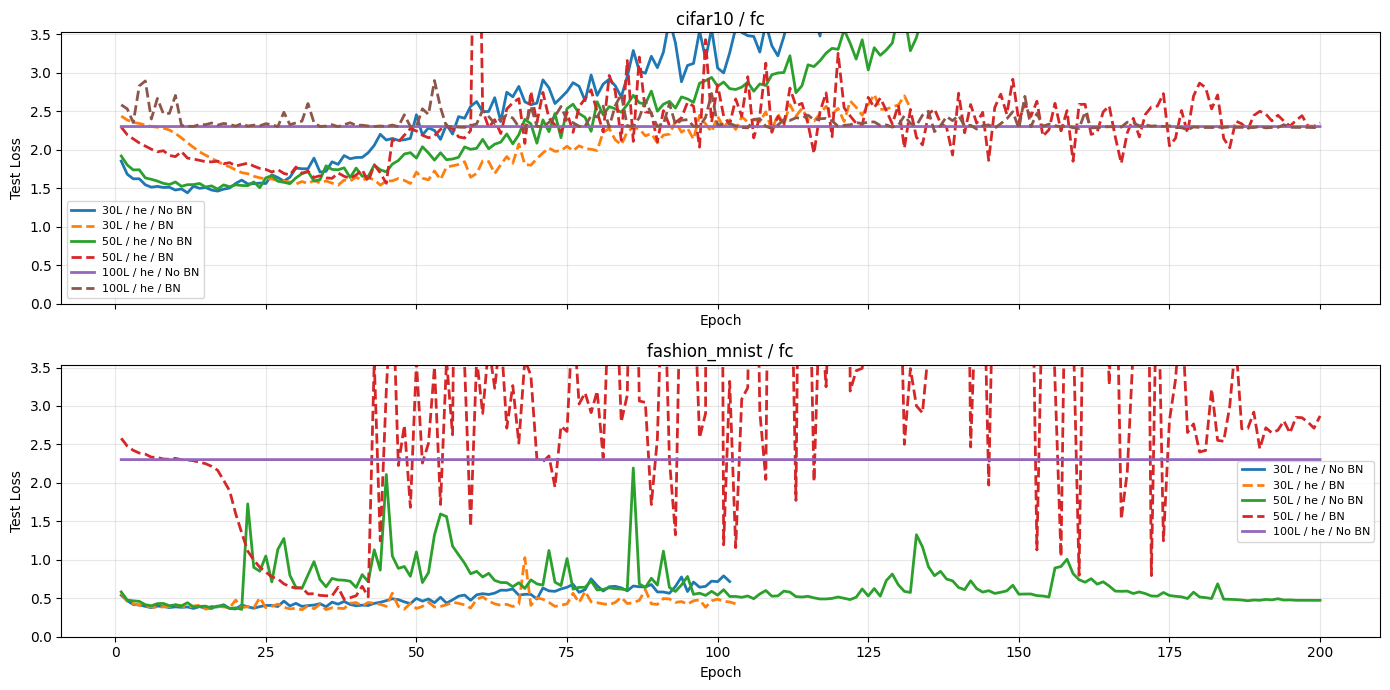

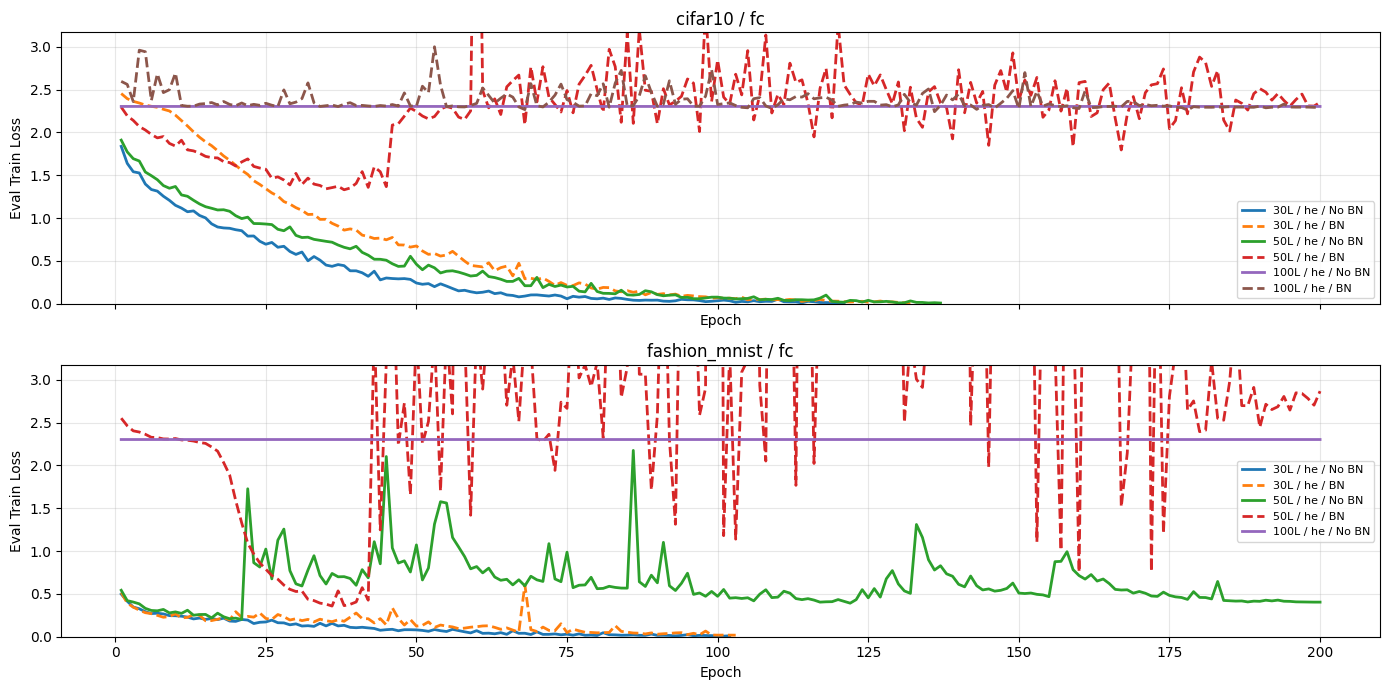

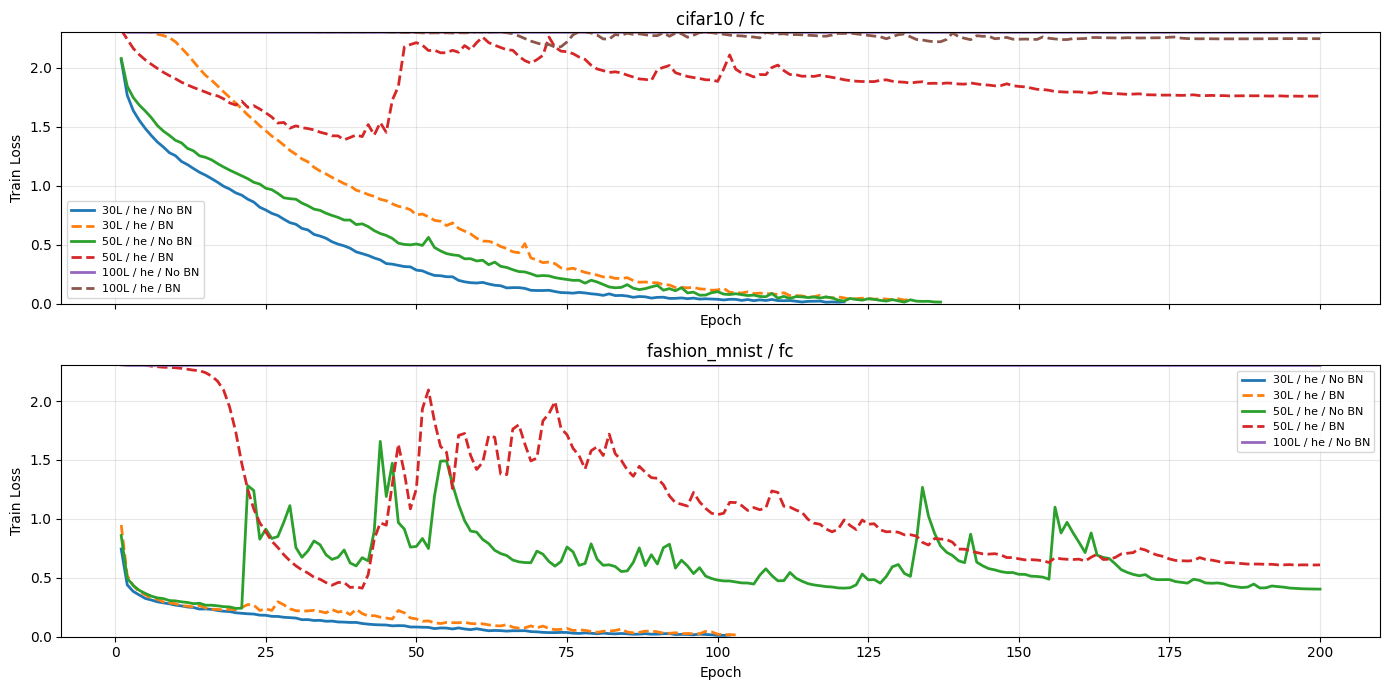

In [8]:
LOSS_CAP_PERCENTILE = 95
TEST_LOSS_CAP = percentile_cap(results, 'test_loss', q=LOSS_CAP_PERCENTILE)
TRAIN_LOSS_CAP = percentile_cap(results, 'train_loss', q=LOSS_CAP_PERCENTILE)
EVAL_TRAIN_LOSS_CAP = percentile_cap(results, 'eval_train_loss', q=LOSS_CAP_PERCENTILE)

print(f'Test-loss cap ({LOSS_CAP_PERCENTILE}th percentile):        {TEST_LOSS_CAP:.4f}')
print(f'Train-mode loss cap ({LOSS_CAP_PERCENTILE}th percentile):  {TRAIN_LOSS_CAP:.4f}')
print(f'Eval-train loss cap ({LOSS_CAP_PERCENTILE}th percentile):  {EVAL_TRAIN_LOSS_CAP:.4f}')

plot_metric_grid(results, metric='test_accuracy', figsize=(14, 7))
plt.show()

plot_metric_grid(results, metric='eval_train_accuracy', figsize=(14, 7))
plt.show()

plot_metric_grid(results, metric='train_accuracy', figsize=(14, 7))
plt.show()

plot_metric_grid(results, metric='test_loss', figsize=(14, 7))
plt.show()

plot_metric_grid(results, metric='eval_train_loss', figsize=(14, 7))
plt.show()

plot_metric_grid(results, metric='train_loss', figsize=(14, 7))
plt.show()

plot_metric_grid(results, metric='test_loss', figsize=(14, 7), yscale='log')
plt.show()

plot_metric_grid(results, metric='eval_train_loss', figsize=(14, 7), yscale='log')
plt.show()

plot_metric_grid(results, metric='train_loss', figsize=(14, 7), yscale='log')
plt.show()

plot_metric_grid(results, metric='test_loss', figsize=(14, 7), ymax=TEST_LOSS_CAP)
plt.show()

plot_metric_grid(results, metric='eval_train_loss', figsize=(14, 7), ymax=EVAL_TRAIN_LOSS_CAP)
plt.show()

plot_metric_grid(results, metric='train_loss', figsize=(14, 7), ymax=TRAIN_LOSS_CAP)
plt.show()


## Depth Panels

These plots make BN vs No-BN comparisons easier to read because each depth gets its own panel.

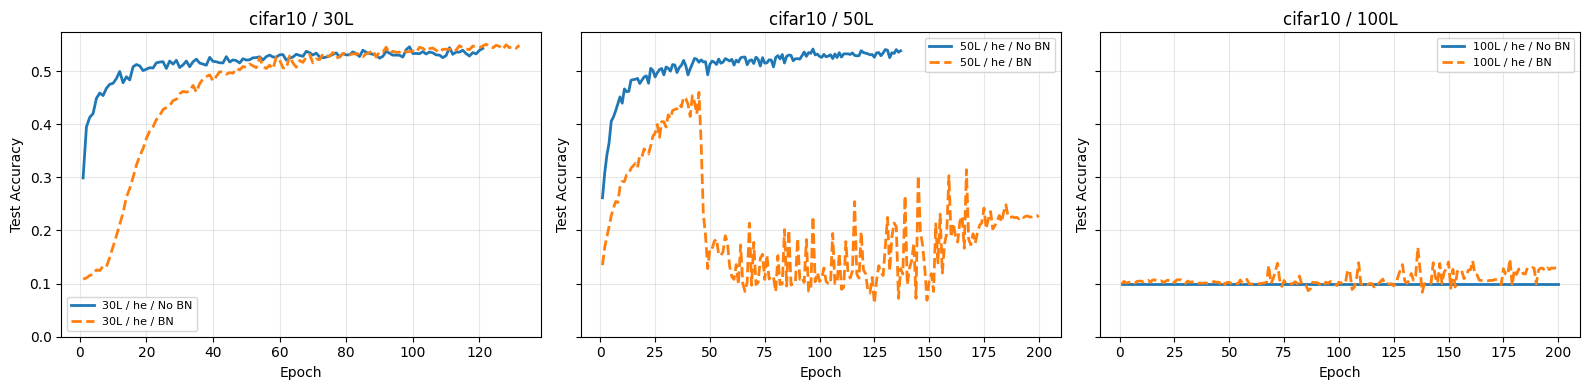

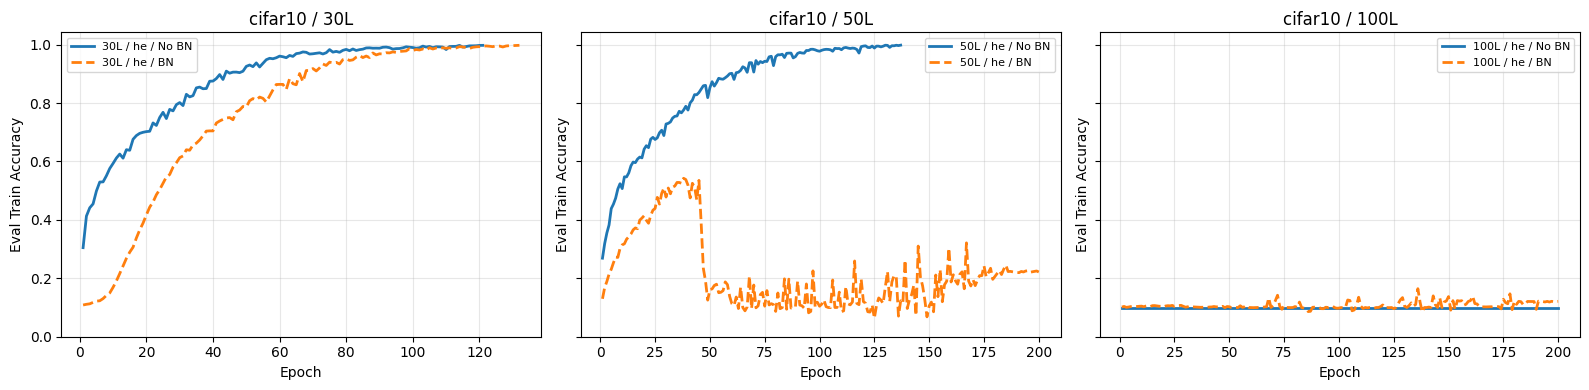

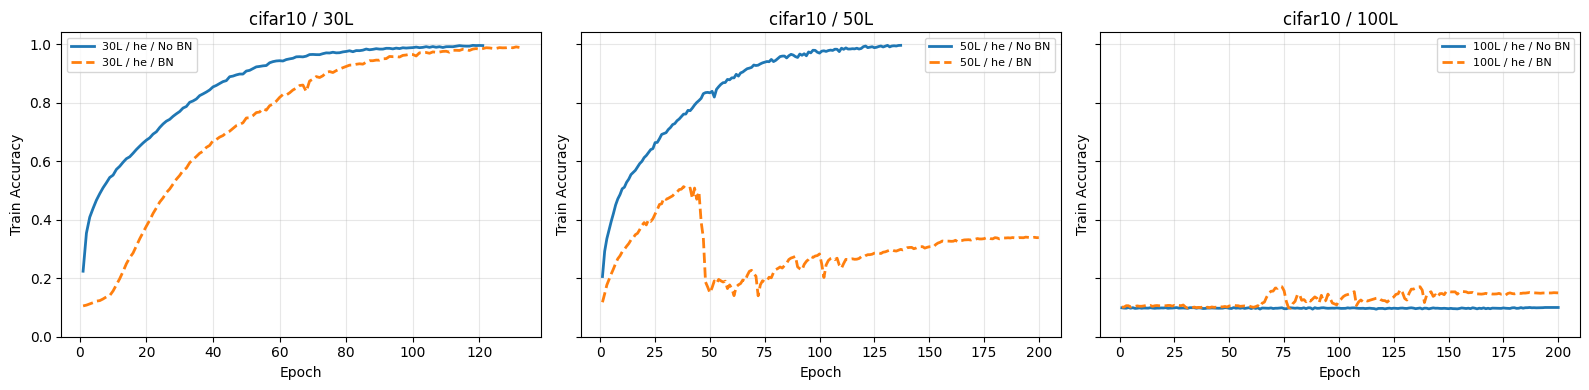

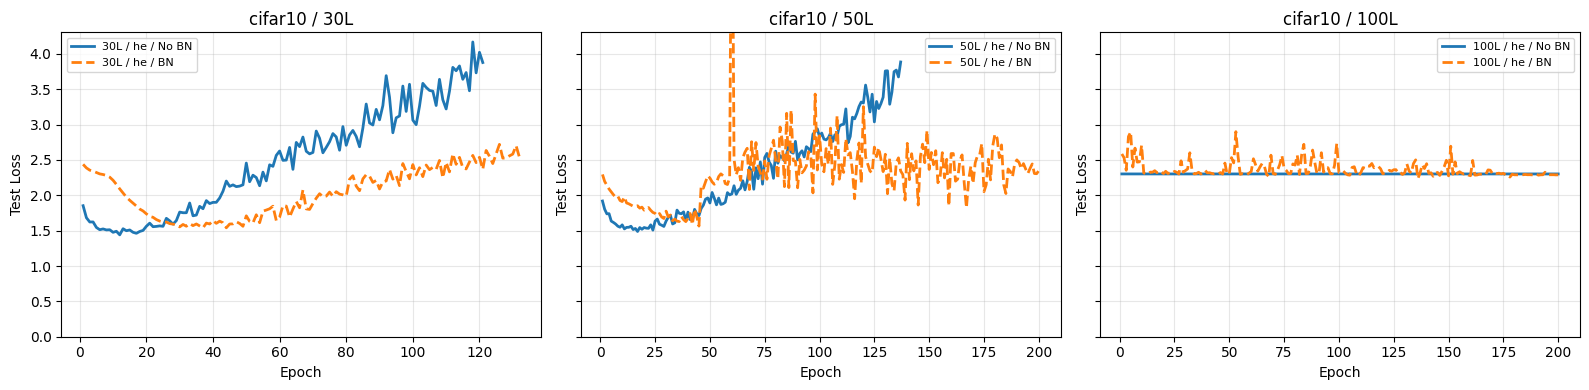

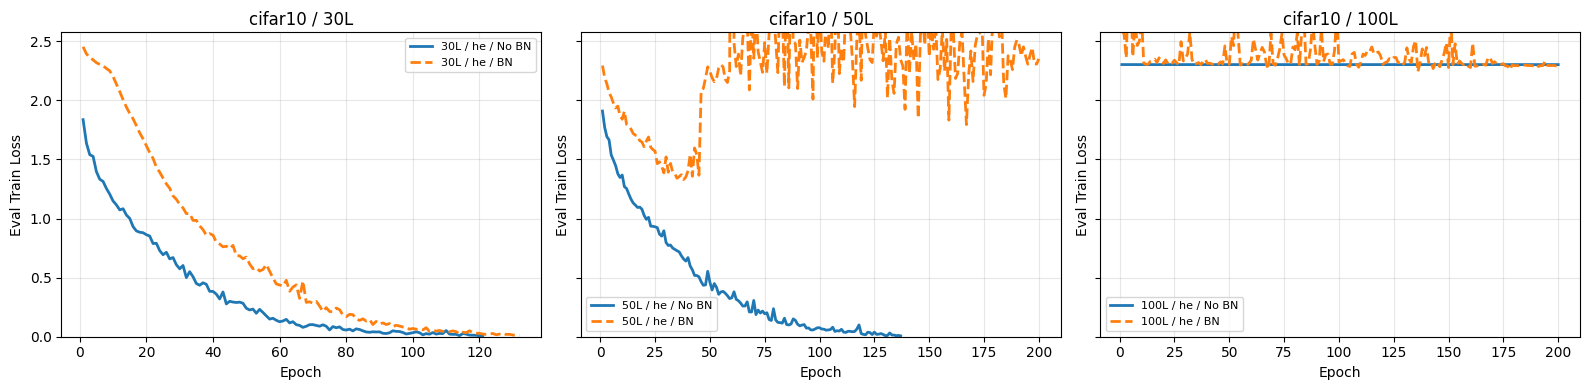

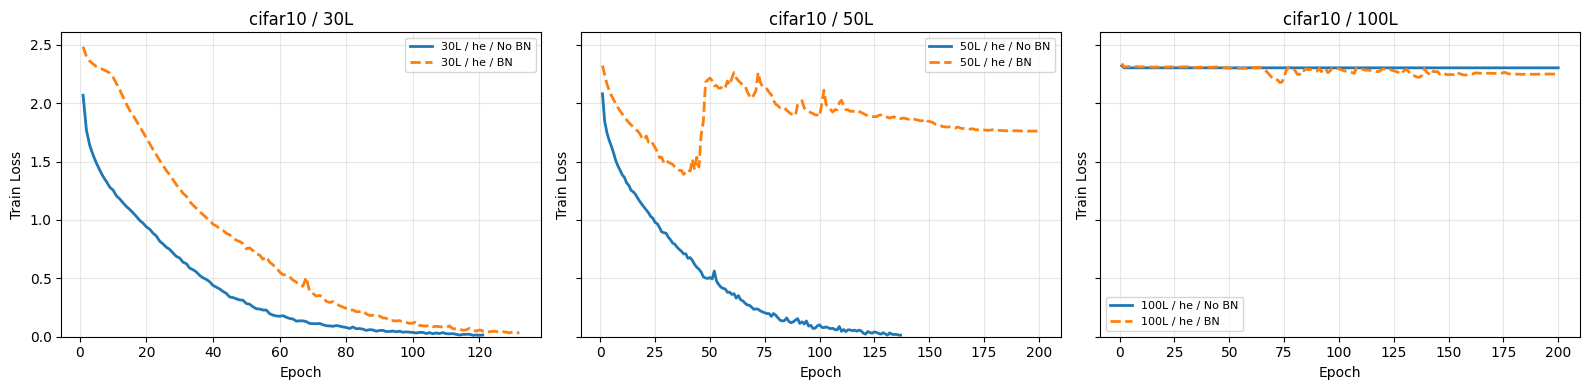

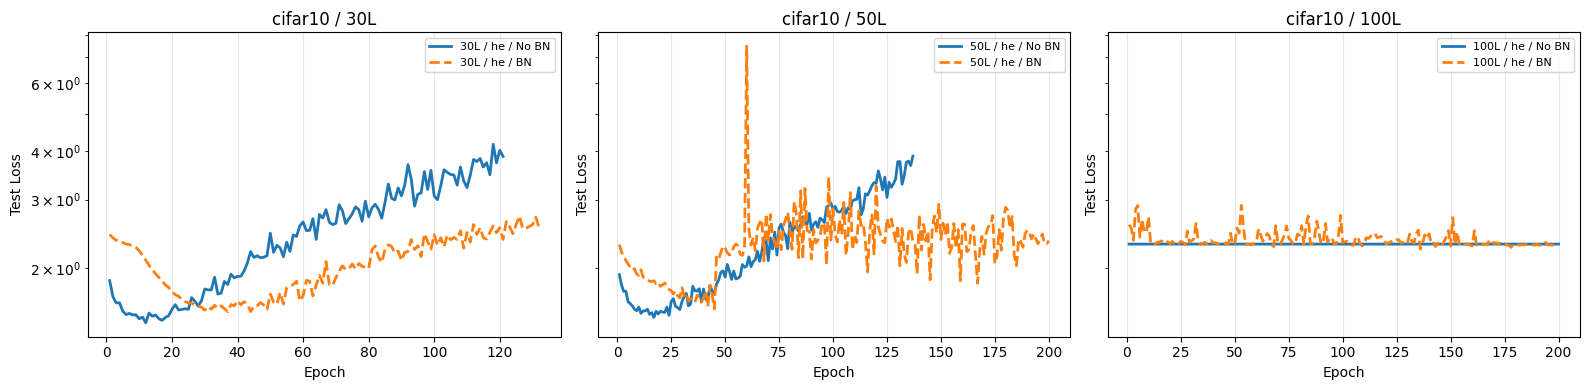

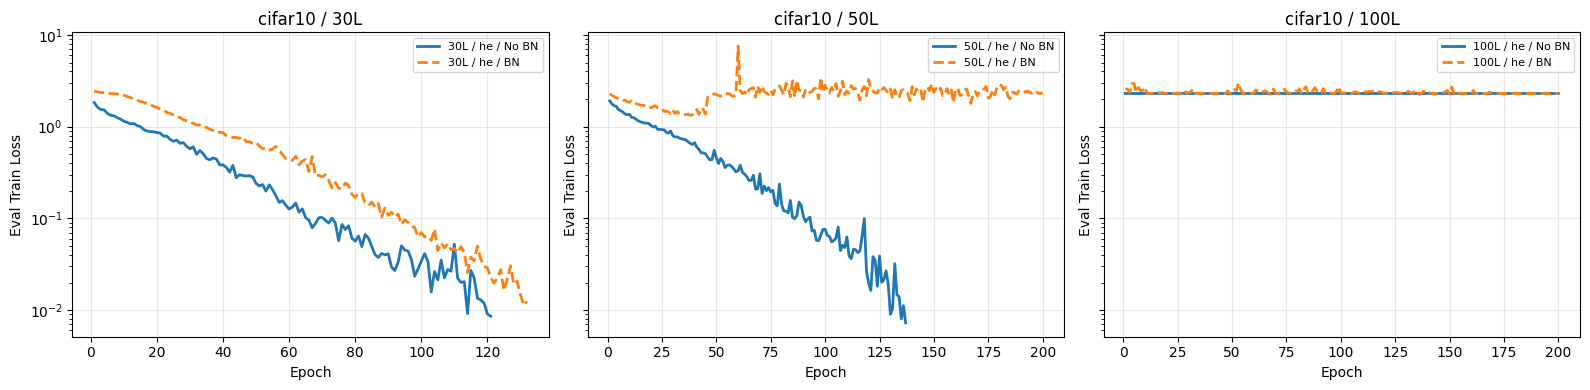

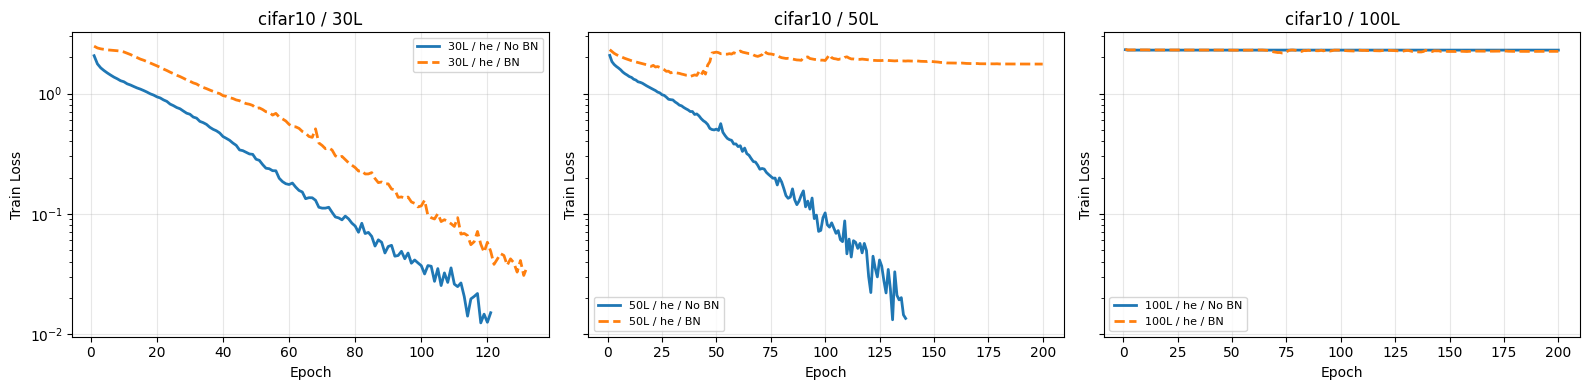

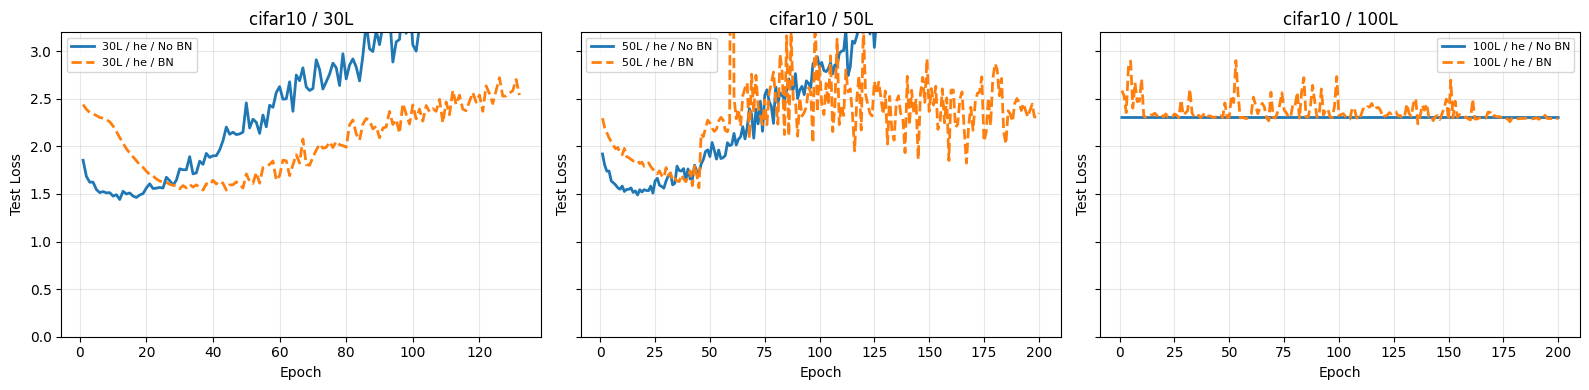

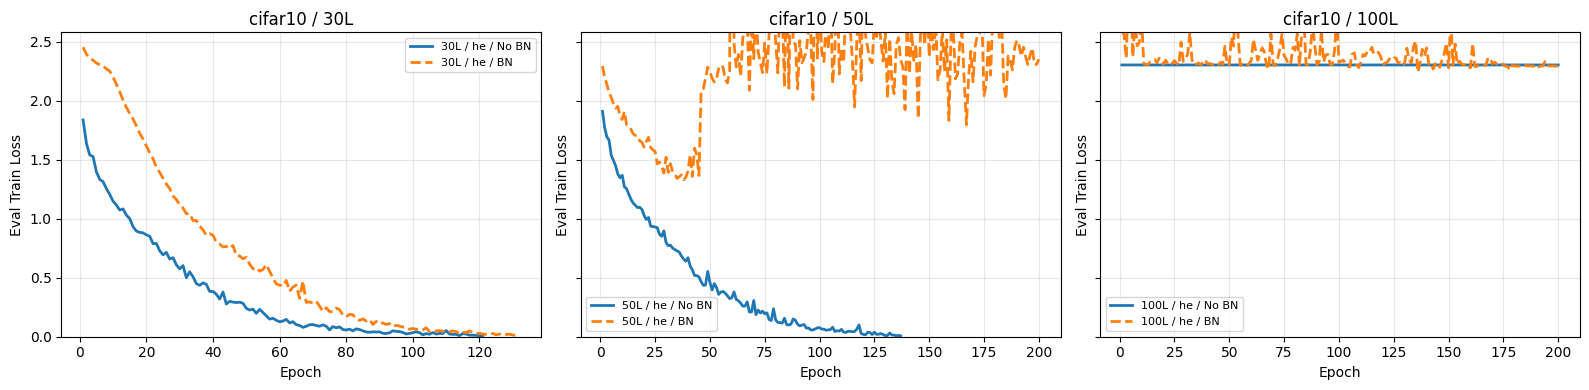

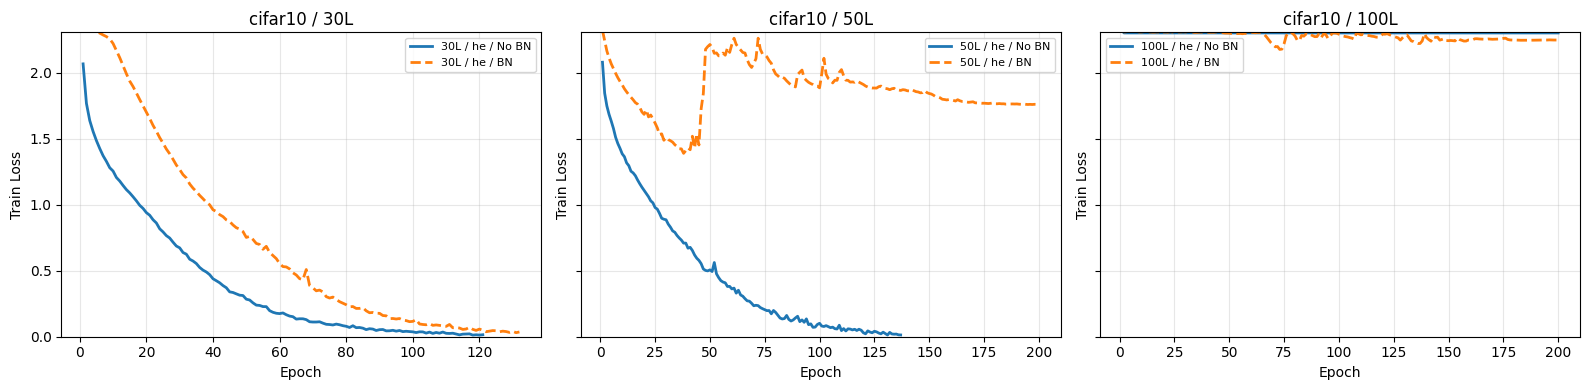

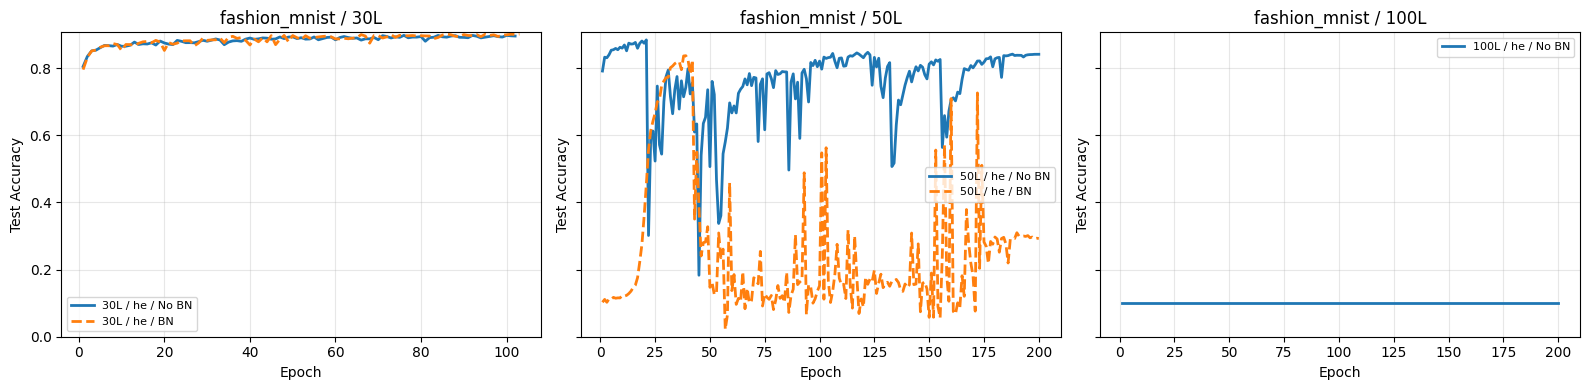

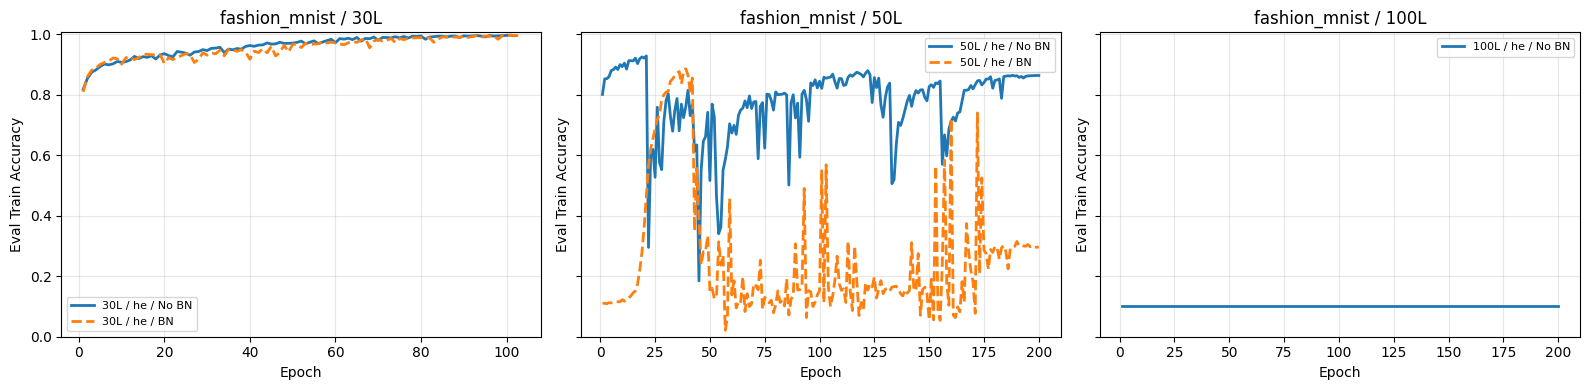

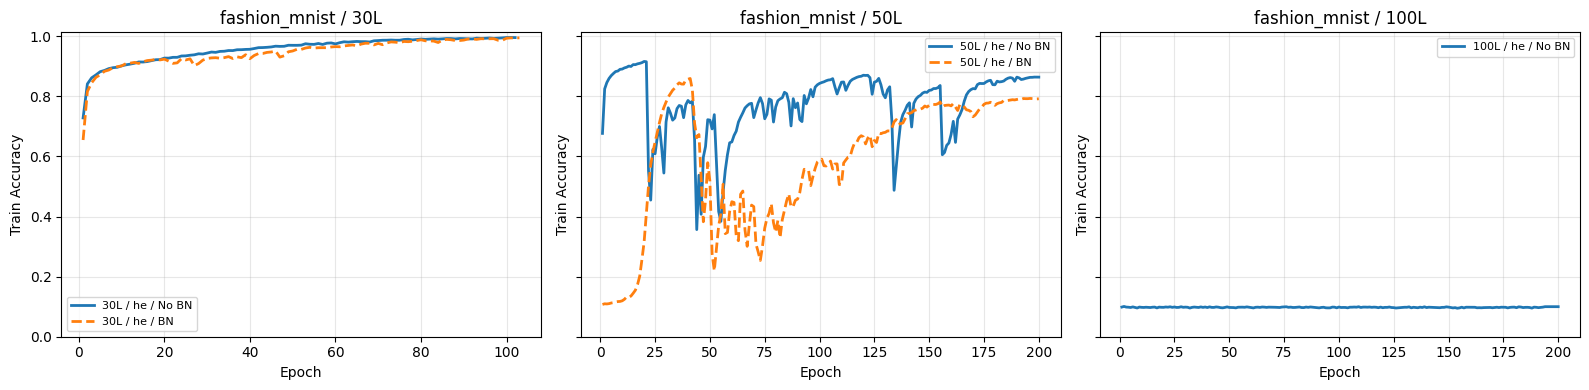

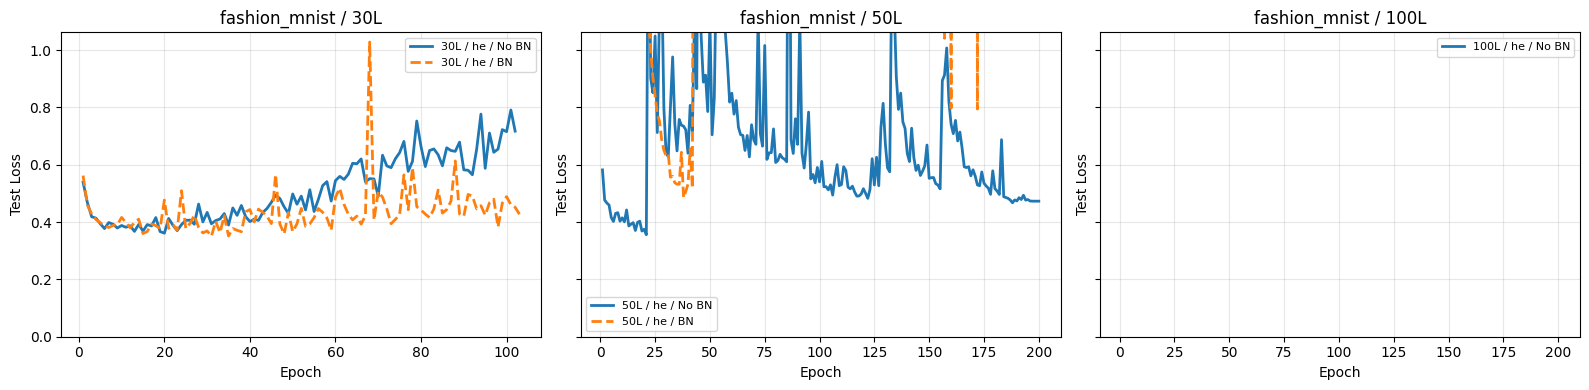

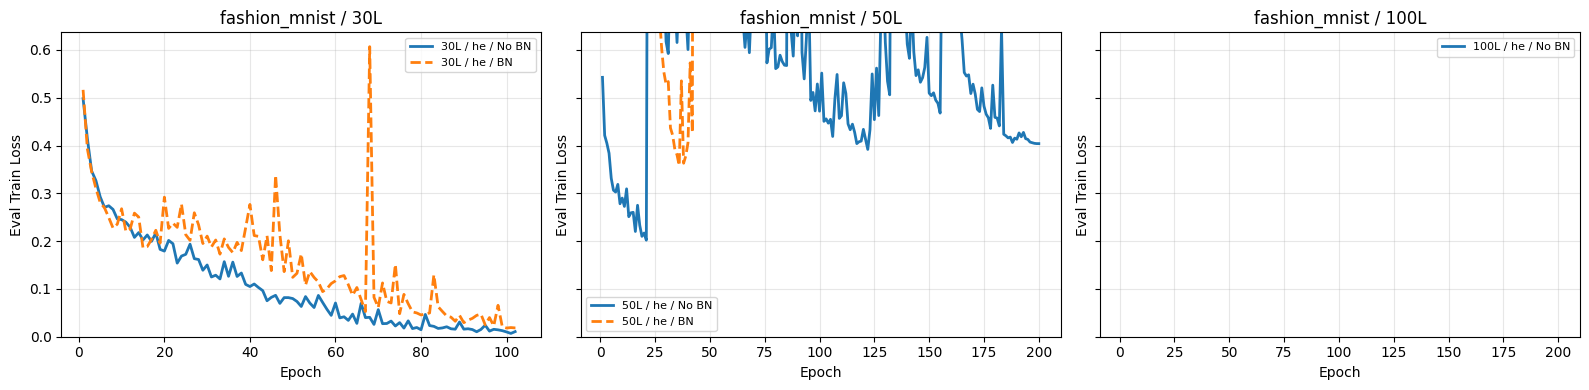

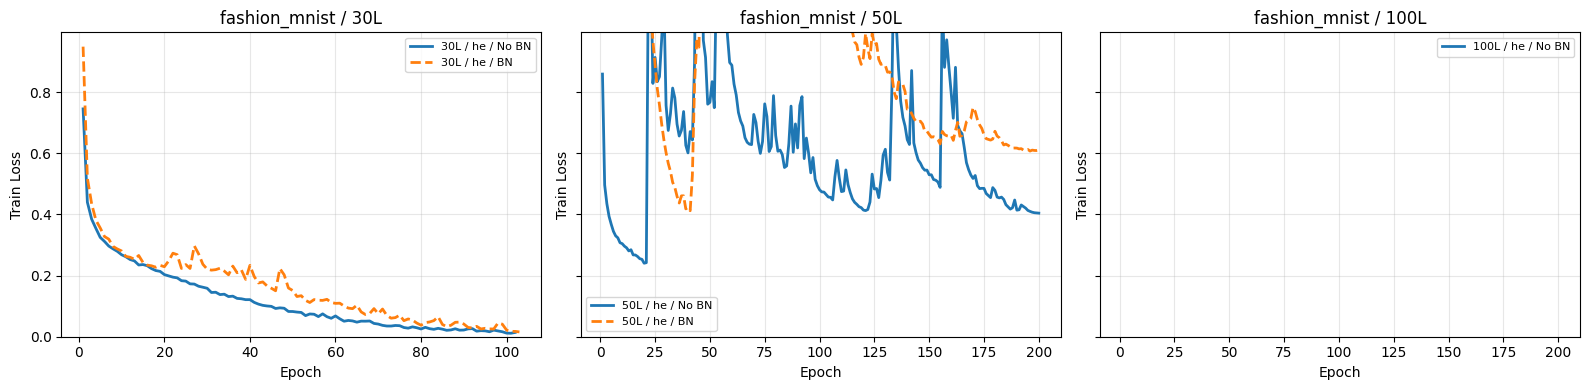

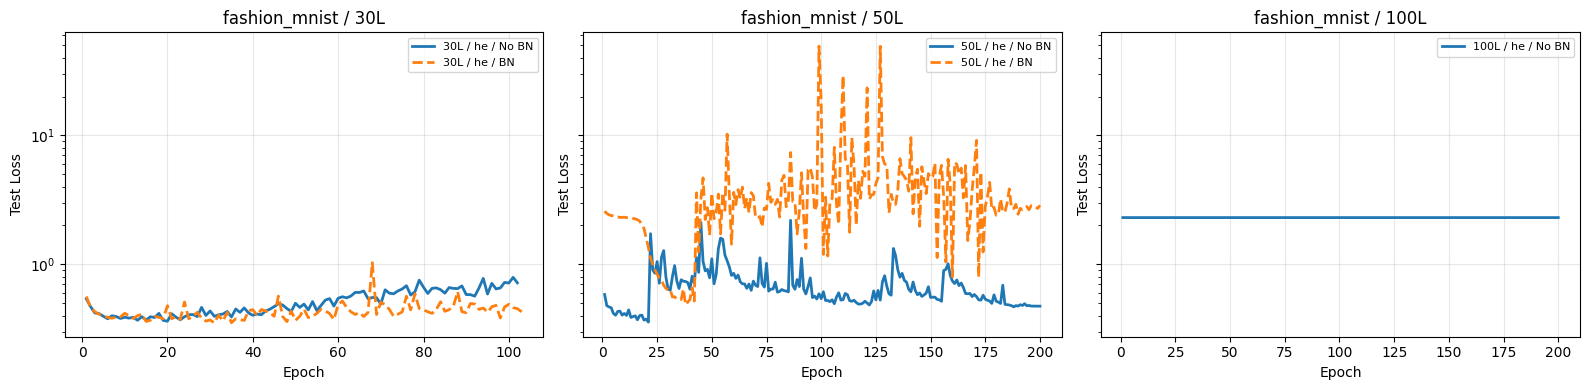

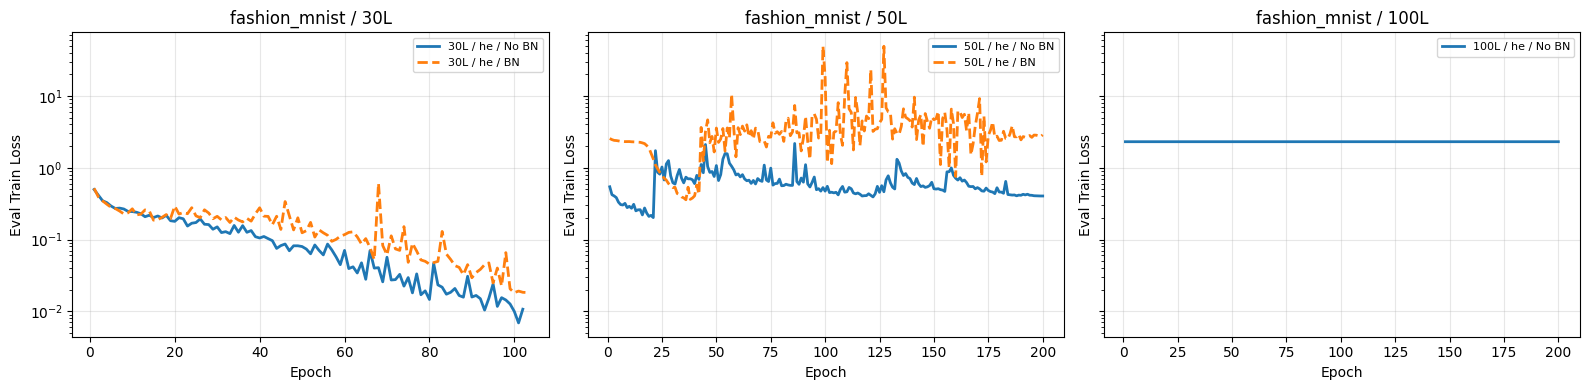

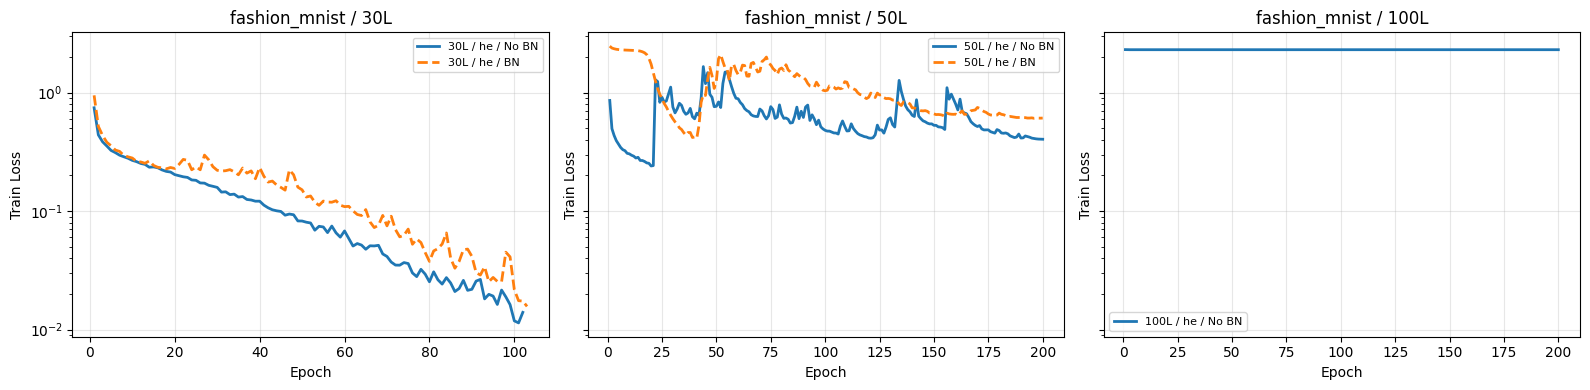

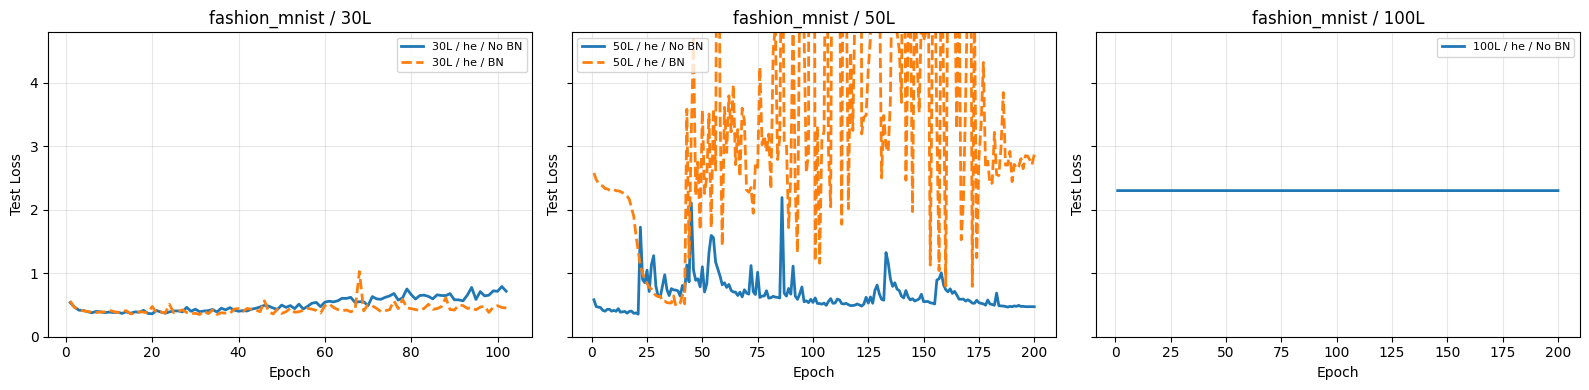

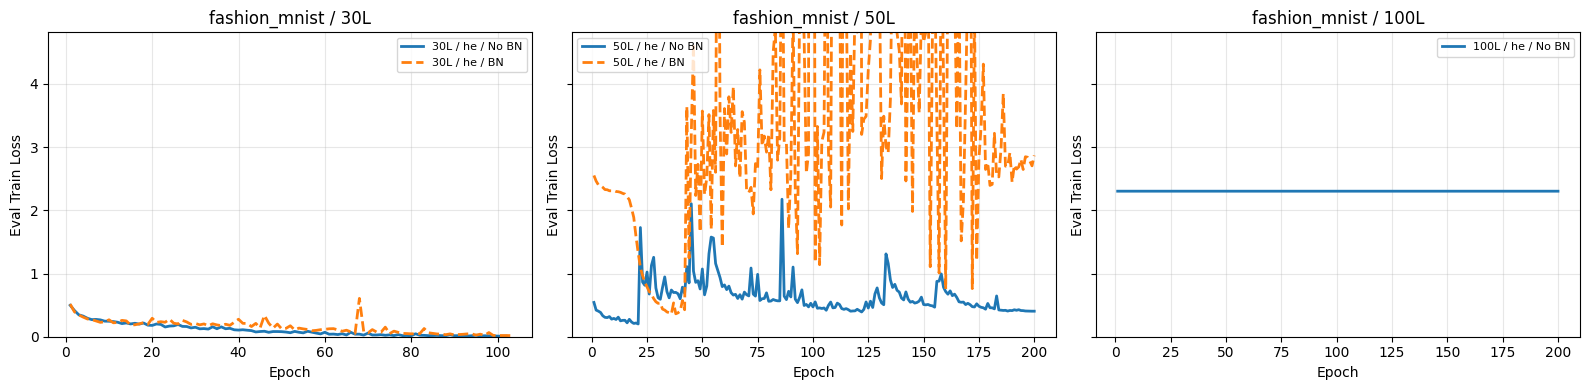

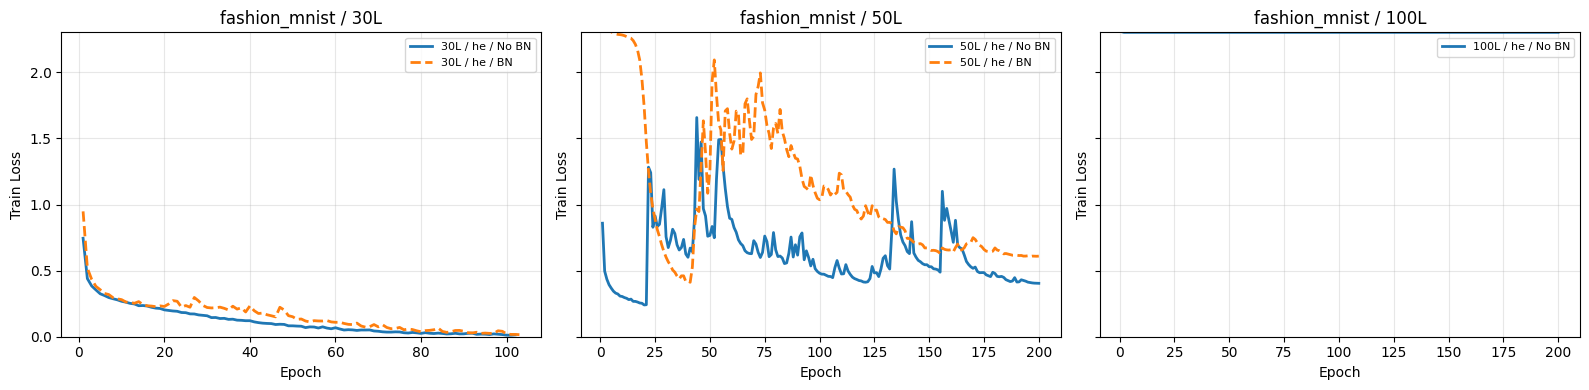

In [9]:
for dataset in sorted({r.training_config['dataset'] for r in results}):
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='test_accuracy', figsize=(16, 4))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='eval_train_accuracy', figsize=(16, 4))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='train_accuracy', figsize=(16, 4))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='test_loss', figsize=(16, 4))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='eval_train_loss', figsize=(16, 4))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='train_loss', figsize=(16, 4))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='test_loss', figsize=(16, 4), yscale='log')
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='eval_train_loss', figsize=(16, 4), yscale='log')
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='train_loss', figsize=(16, 4), yscale='log')
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='test_loss', figsize=(16, 4), ymax=percentile_cap(results, 'test_loss', q=LOSS_CAP_PERCENTILE, dataset=dataset, architecture='fc'))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='eval_train_loss', figsize=(16, 4), ymax=percentile_cap(results, 'eval_train_loss', q=LOSS_CAP_PERCENTILE, dataset=dataset, architecture='fc'))
    plt.show()
    plot_depth_panels(results, dataset=dataset, architecture='fc', metric='train_loss', figsize=(16, 4), ymax=percentile_cap(results, 'train_loss', q=LOSS_CAP_PERCENTILE, dataset=dataset, architecture='fc'))
    plt.show()


## Optional Drilldown

Filtered runs: 2
100L / No BN: status=completed, stop=max_epochs, best_test=0.1000, final_eval_train=0.1000, final_train_mode=0.1000
100L / BN: status=completed, stop=max_epochs, best_test=0.1681, final_eval_train=0.1211, final_train_mode=0.1500


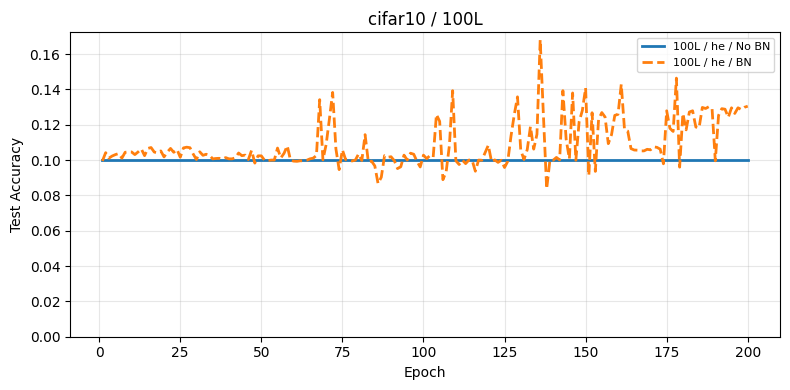

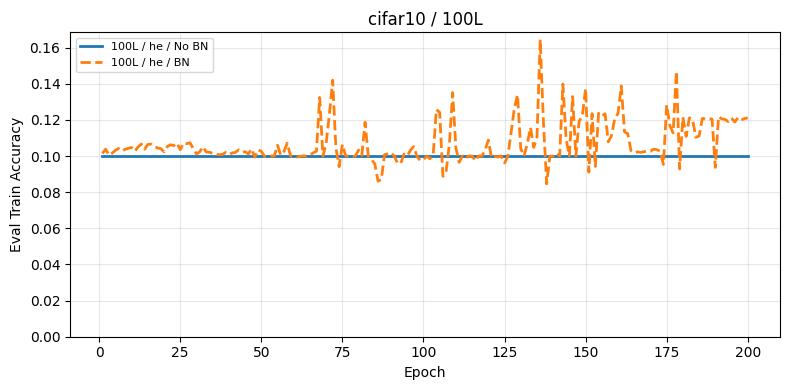

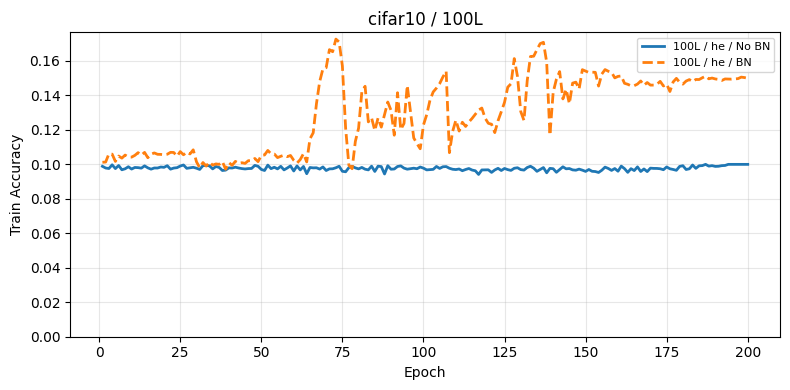

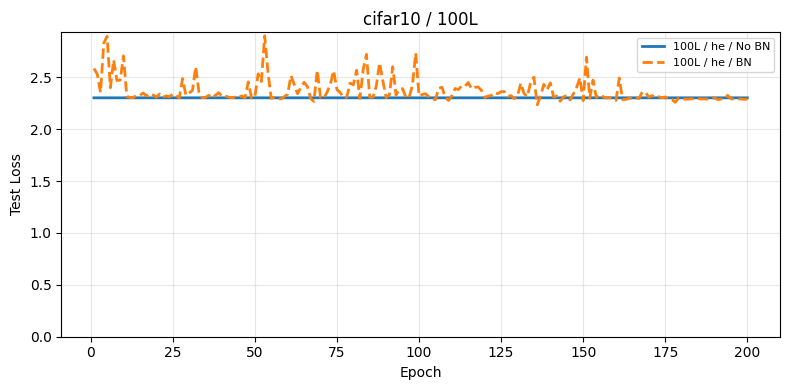

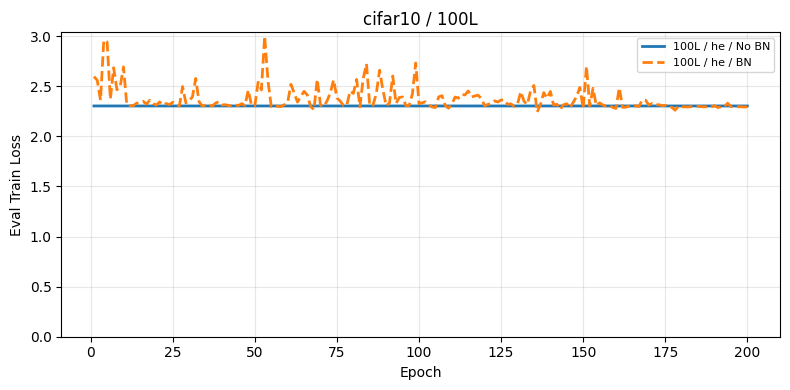

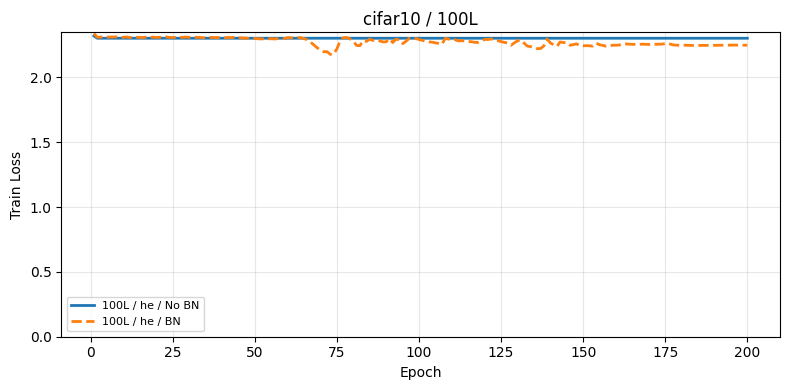

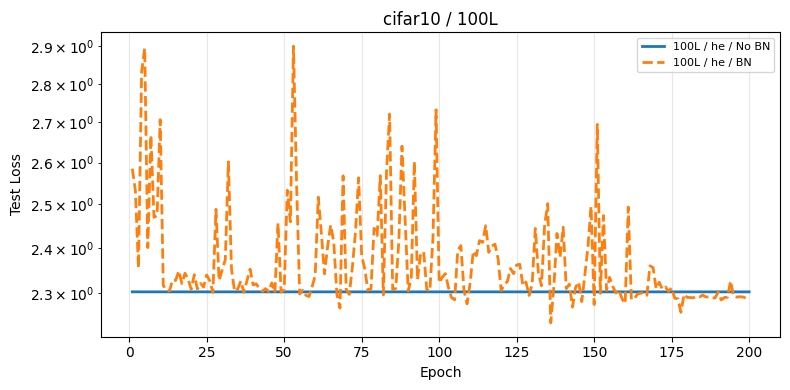

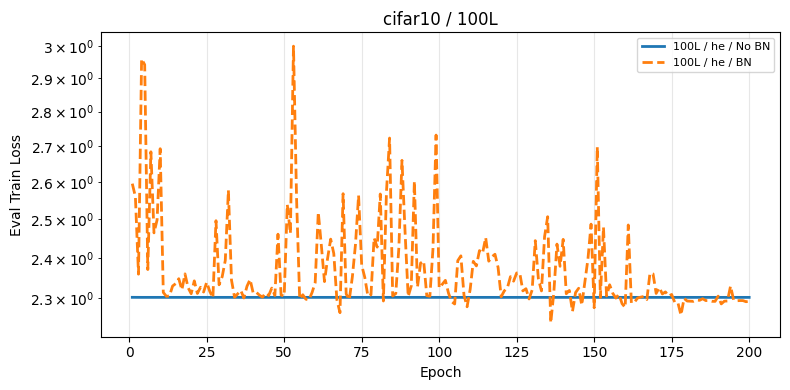

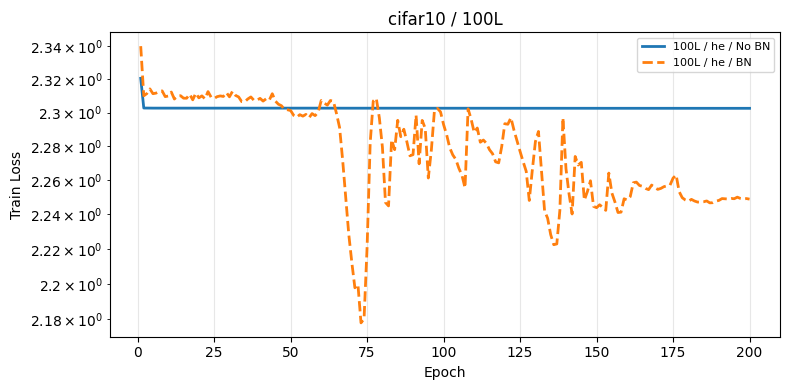

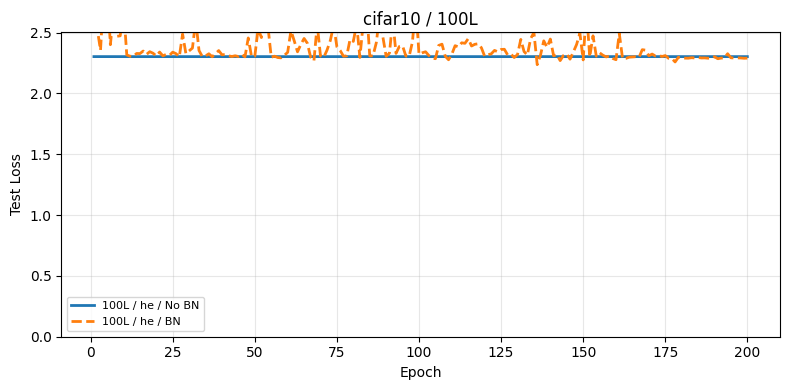

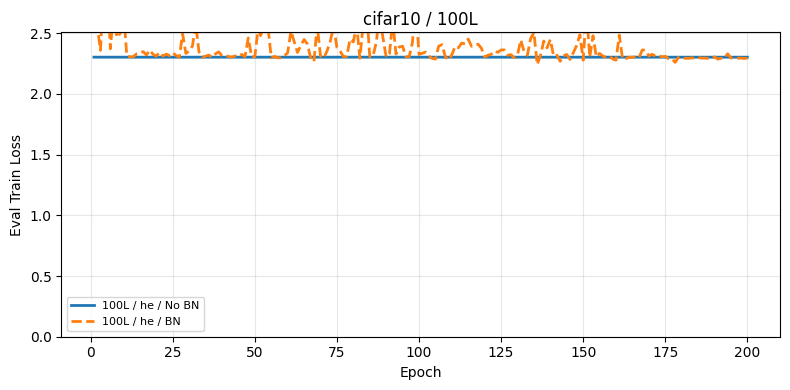

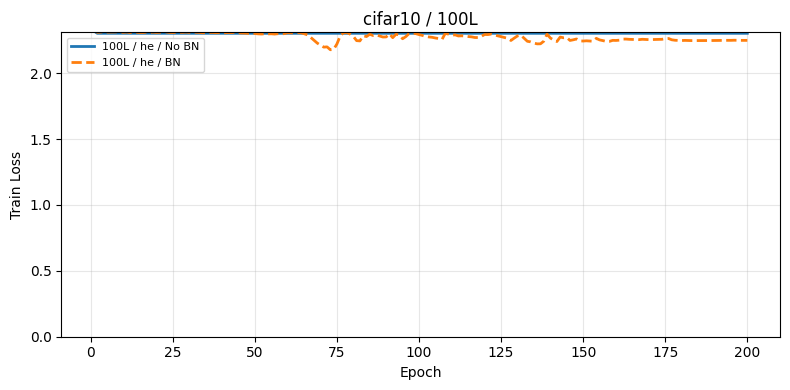

In [10]:
FILTER_DATASET = 'cifar10'
FILTER_DEPTH = 100

filtered = [
    r for r in results
    if r.training_config['dataset'] == FILTER_DATASET
    and r.classifier_config['architecture'] == 'fc'
    and r.classifier_config['depth'] == FILTER_DEPTH
]

print(f'Filtered runs: {len(filtered)}')
for result in filtered:
    cfg = result.classifier_config
    bn_label = 'BN' if cfg['use_batch_norm'] else 'No BN'
    print(
        f"{cfg['depth']}L / {bn_label}: status={result.status}, stop={result.stop_reason}, "
        f"best_test={result.best_test_accuracy:.4f}, final_eval_train={result.final_eval_train_accuracy:.4f}, "
        f"final_train_mode={result.final_train_accuracy:.4f}"
    )

if filtered:
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='test_accuracy', figsize=(8, 4))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='eval_train_accuracy', figsize=(8, 4))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='train_accuracy', figsize=(8, 4))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='test_loss', figsize=(8, 4))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='eval_train_loss', figsize=(8, 4))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='train_loss', figsize=(8, 4))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='test_loss', figsize=(8, 4), yscale='log')
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='eval_train_loss', figsize=(8, 4), yscale='log')
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='train_loss', figsize=(8, 4), yscale='log')
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='test_loss', figsize=(8, 4), ymax=percentile_cap(filtered, 'test_loss', q=LOSS_CAP_PERCENTILE, dataset=FILTER_DATASET, architecture='fc'))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='eval_train_loss', figsize=(8, 4), ymax=percentile_cap(filtered, 'eval_train_loss', q=LOSS_CAP_PERCENTILE, dataset=FILTER_DATASET, architecture='fc'))
    plt.show()
    plot_depth_panels(filtered, dataset=FILTER_DATASET, architecture='fc', metric='train_loss', figsize=(8, 4), ymax=percentile_cap(filtered, 'train_loss', q=LOSS_CAP_PERCENTILE, dataset=FILTER_DATASET, architecture='fc'))
    plt.show()
